In [2]:
import os
import random
import pickle
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchmetrics import MeanAbsoluteError
from tqdm.notebook import tqdm
from time import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    auc,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
BATCH_SIZE = 64
NUM_WORKERS = 0

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

rng = np.random.default_rng(SEED)
seed_everything()

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def inspect_pickle_dataset(pkl_path):
    pkl_path = Path(pkl_path)
    if not pkl_path.exists():
        raise FileNotFoundError(f"Dataset file not found: {pkl_path}")

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    print(f"Loaded type: {type(data)}")

    if isinstance(data, dict):
        print(f"Top-level keys: {list(data.keys())}")
        for k, v in data.items():
            try:
                shape = np.shape(v)
            except Exception:
                shape = "unavailable"
            print(f"  {k}: type={type(v)}, shape={shape}")
    elif isinstance(data, (list, tuple)):
        print(f"Length: {len(data)}")
        if len(data) > 0:
            first = data[0]
            print(f"First item type: {type(first)}")
            if isinstance(first, dict):
                print(f"First item keys: {list(first.keys())}")
            elif isinstance(first, (list, tuple)):
                print(f"First item length: {len(first)}")
                for i, x in enumerate(first):
                    try:
                        shape = np.shape(x)
                    except Exception:
                        shape = "unavailable"
                    print(f"  element[{i}]: type={type(x)}, shape={shape}")
    else:
        print("Unrecognized dataset container. Manual inspection will be needed.")

    return data


def to_numpy_image(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    x = np.array(x)

    if x.ndim == 3 and x.shape[0] in [1, 3]:
        x = np.transpose(x, (1, 2, 0))

    if x.ndim == 3 and x.shape[-1] == 1:
        x = x.squeeze(-1)

    return x


def show_samples(images, labels=None, n=9, cols=3, figsize=(8, 8), cmap="gray"):
    n = min(n, len(images))
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=figsize)

    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        img = to_numpy_image(images[i])
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        if labels is not None:
            plt.title(f"label={labels[i]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    if "train_f1" in history and "val_f1" in history:
        plt.subplot(1, 2, 2)
        plt.plot(epochs, history["train_f1"], label="train")
        plt.plot(epochs, history["val_f1"], label="val")
        plt.xlabel("Epoch")
        plt.ylabel("F1")
        plt.title("F1")
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def binary_classification_metrics(y_true, y_prob, threshold=0.5, verbose=True):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    metrics = {
        "f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "y_pred": y_pred,
    }

    if verbose:
        print(f"F1 score: {f1:.4f}")
        print(f"ROC AUC : {roc_auc:.4f}")
        print("Confusion matrix:")
        print(cm)
        print("\nClassification report:")
        print(classification_report(y_true, y_pred, digits=4))

    return metrics


def plot_binary_roc(y_true, y_prob, title="ROC curve"):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.axis("square")
    plt.grid(True, alpha=0.3)
    plt.show()


def regression_mse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return mean_squared_error(y_true, y_pred)


def regression_mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return mean_absolute_error(y_true, y_pred)


def summarize_labels(labels):
    labels = np.asarray(labels).reshape(-1)
    counts = Counter(labels.tolist())
    print("Label distribution:")
    for k in sorted(counts):
        print(f"  class {k}: {counts[k]}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Classify particles in the simple_particle_dataset (binary)

## Loading the Data

In [3]:
PKL_PATH = "simple_particle_dataset.pkl"
with open(PKL_PATH, "rb") as f: simple_data = pickle.load(f)

images = np.array(simple_data["images"], dtype=np.float32)
labels = np.array(simple_data["labels"], dtype=np.float32)

print("Top-level object type:", type(simple_data))
print("Keys:", list(simple_data.keys()))
print("\nImages:")
print("  shape :", images.shape)
print("  dtype :", images.dtype)
print("(N, H, W) = (number of images, height, width)")
print("\nLabels:")
print("  shape :", labels.shape)
print("  dtype :", labels.dtype)
print("labels (N, 3) where each row is [count, y, x]")
print(labels[:10])

count = labels[:, 0]
x_pos = labels[:, 1]
y_pos = labels[:, 2]

print("\nColumn 0 = count label")
print("  unique values:", np.unique(count))
print("  number of class-0 images:", np.sum(count == 0))
print("  number of class-1 images:", np.sum(count == 1))
print("\nColumn 1 = y-position")
print("  min:", y_pos.min(), "max:", y_pos.max())
print("\nColumn 2 = x-position")
print("  min:", x_pos.min(), "max:", x_pos.max())

Top-level object type: <class 'dict'>
Keys: ['images', 'labels']

Images:
  shape : (10000, 64, 64)
  dtype : float32
(N, H, W) = (number of images, height, width)

Labels:
  shape : (10000, 3)
  dtype : float32
labels (N, 3) where each row is [count, y, x]
[[ 1.        24.87655   11.326707 ]
 [ 1.        27.13841    8.074459 ]
 [ 0.         0.         0.       ]
 [ 0.         0.         0.       ]
 [ 1.        18.114408   8.362782 ]
 [ 1.        16.602669   2.0867584]
 [ 1.        28.385077  14.973508 ]
 [ 0.         0.         0.       ]
 [ 1.        21.802204   9.188779 ]
 [ 0.         0.         0.       ]]

Column 0 = count label
  unique values: [0. 1.]
  number of class-0 images: 5000
  number of class-1 images: 5000

Column 1 = y-position
  min: 0.0 max: 29.986725

Column 2 = x-position
  min: 0.0 max: 29.993132


## Visualizing the Data

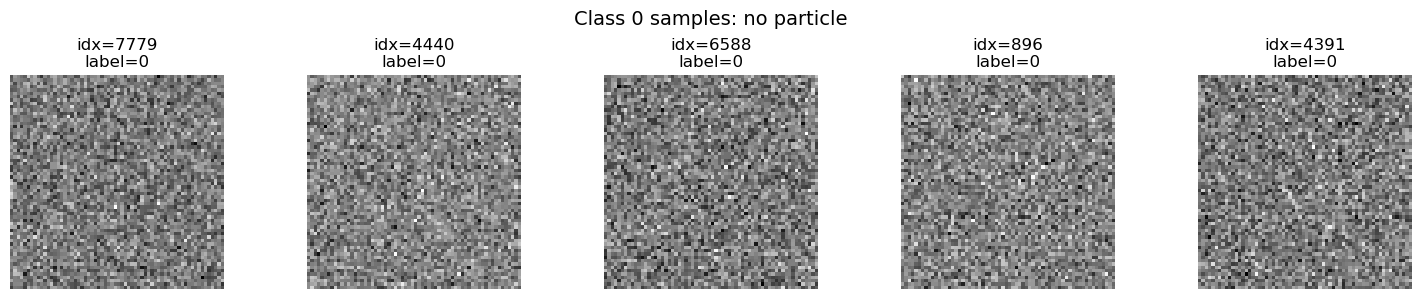

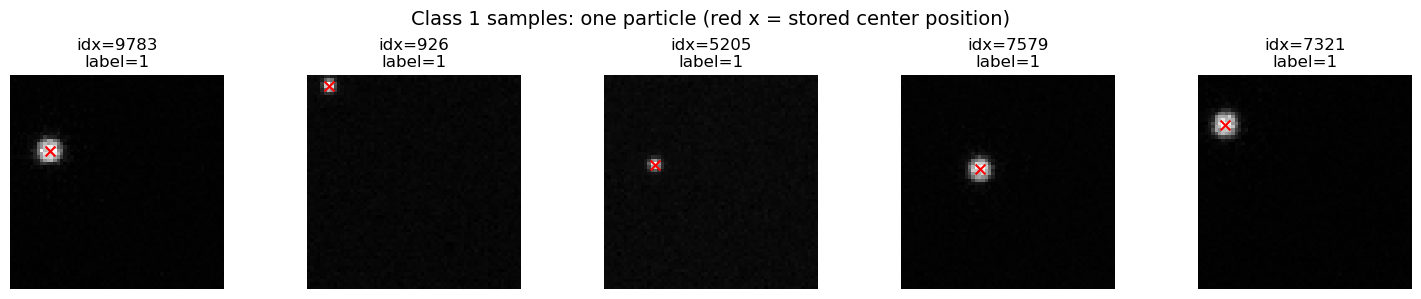

In [4]:
count = labels[:, 0].astype(int)
row_pos = labels[:, 1]   # vertical coordinate
col_pos = labels[:, 2]   # horizontal coordinate
n_show = 5

idx_0 = np.where(count == 0)[0]
idx_1 = np.where(count == 1)[0]
chosen_0 = rng.choice(idx_0, size=n_show, replace=False)
chosen_1 = rng.choice(idx_1, size=n_show, replace=False)

# class-0 sample no particle
plt.figure(figsize=(3 * n_show, 3))
for i, idx in enumerate(chosen_0):
    plt.subplot(1, n_show, i + 1)
    plt.imshow(images[idx], cmap="gray", origin="upper")
    plt.title(f"idx={idx}\nlabel=0")
    plt.axis("off")
plt.suptitle("Class 0 samples: no particle", fontsize=14)
plt.tight_layout()
plt.show()

# class-1 sample one particle
plt.figure(figsize=(3 * n_show, 3))
for i, idx in enumerate(chosen_1):
    plt.subplot(1, n_show, i + 1)
    plt.imshow(images[idx], cmap="gray", origin="upper")
    x = col_pos[idx]
    y = row_pos[idx]
    plt.scatter(x, y, c="red", s=50, marker="x", linewidths=1.5)
    plt.title(f"idx={idx}\nlabel=1")
    plt.axis("off")

plt.suptitle("Class 1 samples: one particle (red x = stored center position)", fontsize=14)
plt.tight_layout()
plt.show()

## Define a custom PyTorch Dataset (binary classification)

In [5]:
class SimpleParticleClassificationDataset(Dataset):
    def __init__(self, images, labels):
        """
        images: numpy array of shape (N, 64, 64)
        labels: numpy array of shape (N, 3) with columns [count, row, col]
        """
        self.images = images.astype(np.float32)
        self.labels = labels.astype(np.float32)
        self.count_labels = self.labels[:, 0].astype(np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # one grayscale image of shape (64, 64)
        image = self.images[idx]
        # channel dimension so PyTorch sees it as (C, H, W) = (1, 64, 64)
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        # Binary label
        label = torch.tensor(self.count_labels[idx], dtype=torch.float32)
        return image, label

# full dataset object
full_dataset = SimpleParticleClassificationDataset(images, labels)

print("Length of data:", len(full_dataset))
sample_image, sample_label = full_dataset[0]
print("Sample image tensor shape:", sample_image.shape)   # (1, 64, 64)
print("Sample image dtype:", sample_image.dtype)
print("Sample label:", sample_label.item())
print("Sample label dtype:", sample_label.dtype)

all_targets = np.array([full_dataset[i][1].item() for i in range(len(full_dataset))], dtype=np.int64)
print("\nClass distribution:")
print("Class 0:", np.sum(all_targets == 0))
print("Class 1:", np.sum(all_targets == 1))

Length of data: 10000
Sample image tensor shape: torch.Size([1, 64, 64])
Sample image dtype: torch.float32
Sample label: 1.0
Sample label dtype: torch.float32

Class distribution:
Class 0: 5000
Class 1: 5000


## Split data into train / validation / test

In [6]:
# 70% train, 15% test, 15% val
n_total = len(full_dataset)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val  # ensures the split sums exactly to N

print("Total samples :", n_total)
print("Train samples :", n_train)
print("Val samples   :", n_val)
print("Test samples  :", n_test)

split_generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=split_generator,
)

print("\nSplit sizes:")
print("len(train_dataset):", len(train_dataset))
print("len(val_dataset)  :", len(val_dataset))
print("len(test_dataset) :", len(test_dataset))

Total samples : 10000
Train samples : 7000
Val samples   : 1500
Test samples  : 1500

Split sizes:
len(train_dataset): 7000
len(val_dataset)  : 1500
len(test_dataset) : 1500


In [7]:
def get_subset_targets(subset):
    return np.array(
        [subset[i][1].item() for i in range(len(subset))],
        dtype=np.int64
    )

y_train = get_subset_targets(train_dataset)
y_val = get_subset_targets(val_dataset)
y_test = get_subset_targets(test_dataset)
print("Train -  class 0:", np.sum(y_train == 0), " class 1:", np.sum(y_train == 1))
print("Val   -  class 0:", np.sum(y_val == 0),   " class 1:", np.sum(y_val == 1))
print("Test  -  class 0:", np.sum(y_test == 0),  " class 1:", np.sum(y_test == 1))

Train -  class 0: 3511  class 1: 3489
Val   -  class 0: 747  class 1: 753
Test  -  class 0: 742  class 1: 758


In [8]:
# dataloaders for train / val / test
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Number of batches:")
print("Train loader:", len(train_loader))
print("Val loader  :", len(val_loader))
print("Test loader :", len(test_loader))

batch_images, batch_labels = next(iter(train_loader))
print("\nOne training batch:")
print("batch_images shape:", batch_images.shape)   # (B, 1, 64, 64)
print("batch_images dtype:", batch_images.dtype)
print("batch_labels shape:", batch_labels.shape)   # (B,)
print("batch_labels dtype:", batch_labels.dtype)
print("First 10 labels in batch:", batch_labels[:10].numpy())

Number of batches:
Train loader: 110
Val loader  : 24
Test loader : 24

One training batch:
batch_images shape: torch.Size([64, 1, 64, 64])
batch_images dtype: torch.float32
batch_labels shape: torch.Size([64])
batch_labels dtype: torch.float32
First 10 labels in batch: [0. 1. 1. 0. 0. 1. 0. 0. 0. 1.]


## Baseline CNN architecture A

In [9]:
class CNNClassifierA(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 64x64 -  32x32

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 32x32 -  16x16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, 1)   # one raw logit for binary classification
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)   # shape: (batch_size,)


# Instantiate the model
model_a = CNNClassifierA()
print(model_a)
print("\nTrainable parameters:", count_trainable_parameters(model_a))

CNNClassifierA(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 529217


In [10]:
batch_images, batch_labels = next(iter(train_loader))
with torch.no_grad():
    batch_logits = model_a(batch_images)

print("Input batch shape :", batch_images.shape)
print("Output logits shape:", batch_logits.shape)   # (batch_size,)
print("First 5 logits    :", batch_logits[:5])

Input batch shape : torch.Size([64, 1, 64, 64])
Output logits shape: torch.Size([64])
First 5 logits    : tensor([0.0855, 0.1022, 0.1020, 0.1020, 0.0886])


## Training and evaluation loops for binary classification

In [11]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_a.parameters(), lr=1e-3)
NUM_EPOCHS = 10

def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    for batch_images, batch_labels in dataloader:
        batch_images = batch_images.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        optimizer.zero_grad()

        batch_logits = model(batch_images)
        loss = criterion(batch_logits, batch_labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_images.size(0)

        batch_probs = torch.sigmoid(batch_logits)

        all_probs.extend(batch_probs.detach().cpu().numpy())
        all_labels.extend(batch_labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_f1 = f1_score(np.array(all_labels), (np.array(all_probs) >= 0.5).astype(int))

    return epoch_loss, epoch_f1


def evaluate_one_epoch(model, dataloader, criterion):
    model.eval()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch_images, batch_labels in dataloader:
            batch_images = batch_images.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)

            batch_logits = model(batch_images)
            loss = criterion(batch_logits, batch_labels)

            running_loss += loss.item() * batch_images.size(0)

            batch_probs = torch.sigmoid(batch_logits)

            all_probs.extend(batch_probs.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_f1 = f1_score(np.array(all_labels), (np.array(all_probs) >= 0.5).astype(int))

    return epoch_loss, epoch_f1, np.array(all_labels), np.array(all_probs)


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_f1": [],
        "val_f1": [],
    }

    best_val_f1 = -1.0
    best_state_dict = None

    for epoch in range(num_epochs):
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_f1, _, _ = evaluate_one_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_f1={train_f1:.4f} | val_f1={val_f1:.4f}"
        )

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    print(f"\nBest validation F1: {best_val_f1:.4f}")

    return history

### Train architecture A

Training CNNClassifierA...
Trainable parameters: 529217
Epoch 01/10 | train_loss=0.0646 | val_loss=0.0000 | train_f1=0.9645 | val_f1=1.0000
Epoch 02/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 03/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 04/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 05/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 06/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 07/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 08/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 09/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 10/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000

Best validation F1: 1.0000


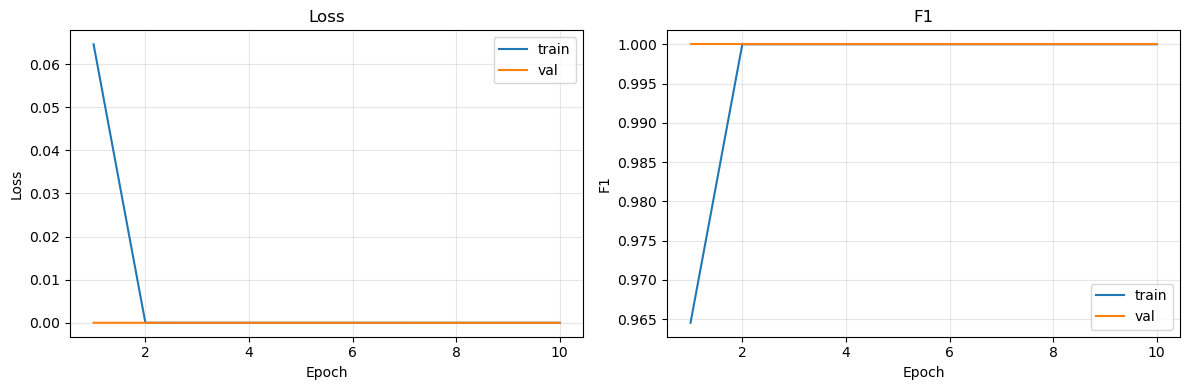

In [12]:
model_a = CNNClassifierA().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_a.parameters(), lr=1e-3)

print("Training CNNClassifierA...")
print("Trainable parameters:", count_trainable_parameters(model_a))

history_a = train_model(
    model=model_a,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
)

plot_training_history(history_a)

Test loss (A): 0.0000
Test F1   (A): 1.0000
F1 score: 1.0000
ROC AUC : 1.0000
Confusion matrix:
[[742   0]
 [  0 758]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       742
           1     1.0000    1.0000    1.0000       758

    accuracy                         1.0000      1500
   macro avg     1.0000    1.0000    1.0000      1500
weighted avg     1.0000    1.0000    1.0000      1500



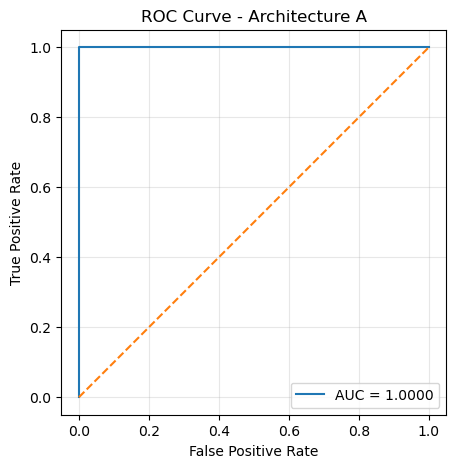

In [13]:
# test architecture A and plot ROC
test_loss_a, test_f1_a, y_test_true_a, y_test_prob_a = evaluate_one_epoch(
    model=model_a,
    dataloader=test_loader,
    criterion=criterion,
)

print(f"Test loss (A): {test_loss_a:.4f}")
print(f"Test F1   (A): {test_f1_a:.4f}")

metrics_a = binary_classification_metrics(
    y_true=y_test_true_a,
    y_prob=y_test_prob_a,
    threshold=0.5,
    verbose=True,
)

plot_binary_roc(
    y_true=y_test_true_a,
    y_prob=y_test_prob_a,
    title="ROC Curve - Architecture A"
)

results_a = {
    "name": "Architecture A",
    "params": count_trainable_parameters(model_a),
    "val_f1_best": max(history_a["val_f1"]),
    "test_f1": metrics_a["f1"],
    "test_auc": metrics_a["roc_auc"],
}

### Define CNN architecture B

In [14]:
# Smaller than A- fewer channels and only one pooling step
class CNNClassifierB(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 64x64 -- 32x32

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            # no second pooling layer here*
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 32 * 32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


model_b = CNNClassifierB().to(DEVICE)
print(model_b)
print("\nTrainable parameters:", count_trainable_parameters(model_b))

CNNClassifierB(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 525601


Training CNNClassifierB...
Trainable parameters: 525601
Epoch 01/10 | train_loss=0.0611 | val_loss=0.0001 | train_f1=0.9865 | val_f1=1.0000
Epoch 02/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 03/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 04/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 05/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 06/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 07/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 08/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 09/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 10/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000

Best validation F1: 1.0000


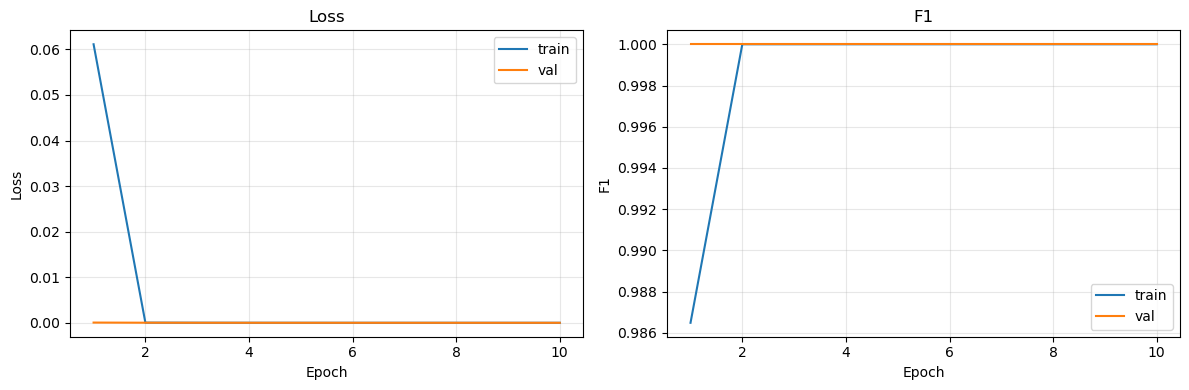

Test loss (B): 0.0001
Test F1   (B): 1.0000
F1 score: 1.0000
ROC AUC : 1.0000
Confusion matrix:
[[742   0]
 [  0 758]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       742
           1     1.0000    1.0000    1.0000       758

    accuracy                         1.0000      1500
   macro avg     1.0000    1.0000    1.0000      1500
weighted avg     1.0000    1.0000    1.0000      1500



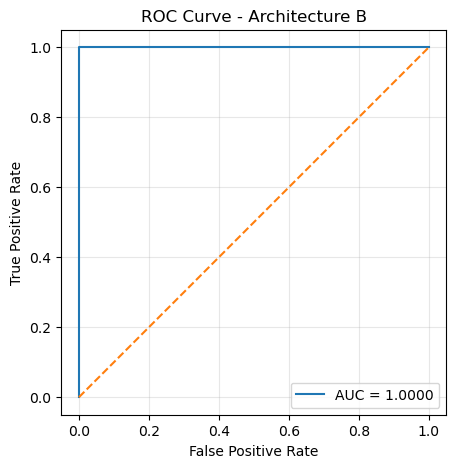

In [15]:
# train and test architecture B
model_b = CNNClassifierB().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_b.parameters(), lr=1e-3)

print("Training CNNClassifierB...")
print("Trainable parameters:", count_trainable_parameters(model_b))

history_b = train_model(
    model=model_b,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
)

plot_training_history(history_b)

test_loss_b, test_f1_b, y_test_true_b, y_test_prob_b = evaluate_one_epoch(
    model=model_b,
    dataloader=test_loader,
    criterion=criterion,
)

print(f"Test loss (B): {test_loss_b:.4f}")
print(f"Test F1   (B): {test_f1_b:.4f}")

metrics_b = binary_classification_metrics(
    y_true=y_test_true_b,
    y_prob=y_test_prob_b,
    threshold=0.5,
    verbose=True,
)

plot_binary_roc(
    y_true=y_test_true_b,
    y_prob=y_test_prob_b,
    title="ROC Curve - Architecture B"
)

results_b = {
    "name": "Architecture B",
    "params": count_trainable_parameters(model_b),
    "val_f1_best": max(history_b["val_f1"]),
    "test_f1": metrics_b["f1"],
    "test_auc": metrics_b["roc_auc"],
}

### Define CNN architecture C

In [16]:
# Deeper model with 3 convolutional layers and larger kernel sizes
class CNNClassifierC(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 64x64 -- 32x32

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 32x32 -- 16x16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


model_c = CNNClassifierC().to(DEVICE)
print(model_c)
print("\nTrainable parameters:", count_trainable_parameters(model_c))

CNNClassifierC(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 270273


Training CNNClassifierC...
Trainable parameters: 270273
Epoch 01/10 | train_loss=0.0770 | val_loss=0.0000 | train_f1=0.9626 | val_f1=1.0000
Epoch 02/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 03/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 04/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 05/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 06/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 07/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 08/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 09/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 10/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000

Best validation F1: 1.0000


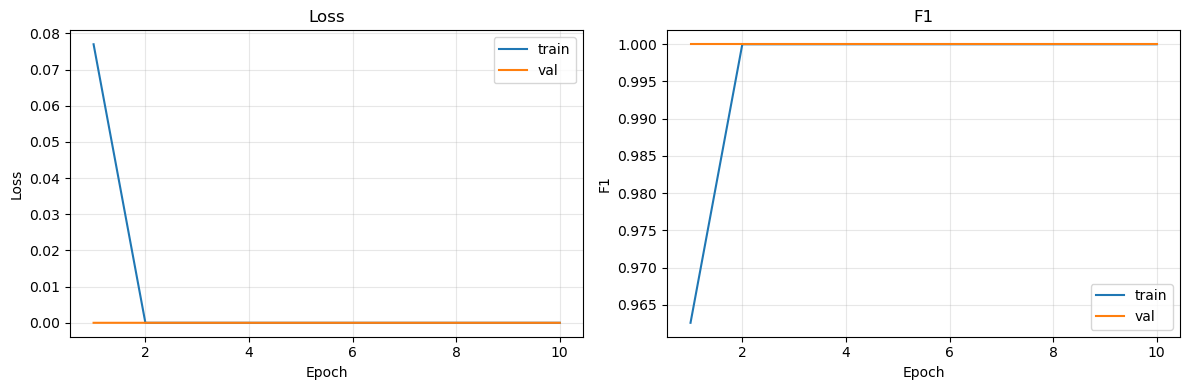

Test loss (C): 0.0000
Test F1   (C): 1.0000
F1 score: 1.0000
ROC AUC : 1.0000
Confusion matrix:
[[742   0]
 [  0 758]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       742
           1     1.0000    1.0000    1.0000       758

    accuracy                         1.0000      1500
   macro avg     1.0000    1.0000    1.0000      1500
weighted avg     1.0000    1.0000    1.0000      1500



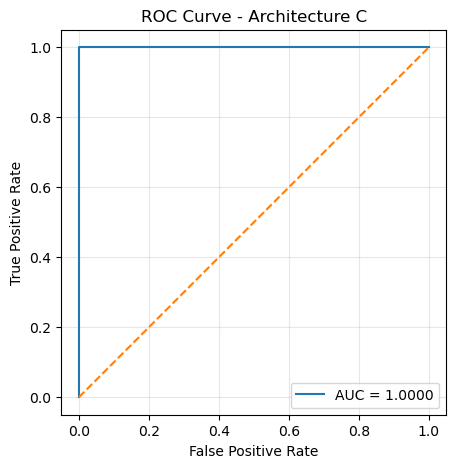

In [17]:
# train and test architecture C
model_c = CNNClassifierC().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_c.parameters(), lr=1e-3)

print("Training CNNClassifierC...")
print("Trainable parameters:", count_trainable_parameters(model_c))

history_c = train_model(
    model=model_c,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
)

plot_training_history(history_c)

test_loss_c, test_f1_c, y_test_true_c, y_test_prob_c = evaluate_one_epoch(
    model=model_c,
    dataloader=test_loader,
    criterion=criterion,
)

print(f"Test loss (C): {test_loss_c:.4f}")
print(f"Test F1   (C): {test_f1_c:.4f}")

metrics_c = binary_classification_metrics(
    y_true=y_test_true_c,
    y_prob=y_test_prob_c,
    threshold=0.5,
    verbose=True,
)

plot_binary_roc(
    y_true=y_test_true_c,
    y_prob=y_test_prob_c,
    title="ROC Curve - Architecture C"
)

results_c = {
    "name": "Architecture C",
    "params": count_trainable_parameters(model_c),
    "val_f1_best": max(history_c["val_f1"]),
    "test_f1": metrics_c["f1"],
    "test_auc": metrics_c["roc_auc"],
}

### Define CNN architecture D

In [19]:
# Much smaller by using adaptive global average pooling
class CNNClassifierD(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 64x64 -- 32x32

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 32x32 -- 16x16

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))   # 16x16 -- 1x1 per channel
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                  # (B, 32, 1, 1) -- (B, 32)
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


model_d = CNNClassifierD().to(DEVICE)
print(model_d)
print("\nTrainable parameters:", count_trainable_parameters(model_d))
batch_images, batch_labels = next(iter(train_loader))

batch_images = batch_images.to(DEVICE)
batch_labels = batch_labels.to(DEVICE)

with torch.no_grad():
    batch_logits = model_d(batch_images)
print("Input batch shape  :", batch_images.shape)
print("Output logits shape:", batch_logits.shape)
print("First 5 logits     :", batch_logits[:5])

CNNClassifierD(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features=16, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)

Trainable parameters: 6433
Input batch shape  : torch.Size([64, 1, 64, 64])
Output logits shape: torch.Size([64])
First 5 logits     : tensor([0.2033, 0.2023, 0.2030, 0.2033, 0.2030], device='cuda:0')


Training CNNClassifierD...
Trainable parameters: 6433
Epoch 01/10 | train_loss=0.3445 | val_loss=0.0091 | train_f1=0.8830 | val_f1=1.0000
Epoch 02/10 | train_loss=0.0017 | val_loss=0.0003 | train_f1=1.0000 | val_f1=1.0000
Epoch 03/10 | train_loss=0.0002 | val_loss=0.0001 | train_f1=1.0000 | val_f1=1.0000
Epoch 04/10 | train_loss=0.0001 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 05/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 06/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 07/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 08/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 09/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000
Epoch 10/10 | train_loss=0.0000 | val_loss=0.0000 | train_f1=1.0000 | val_f1=1.0000

Best validation F1: 1.0000


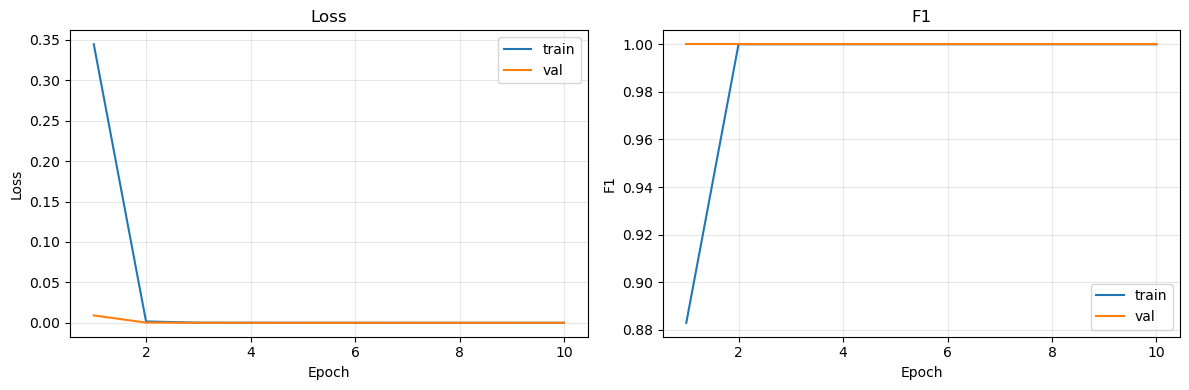

Test loss (D): 0.0091
Test F1   (D): 1.0000
F1 score: 1.0000
ROC AUC : 1.0000
Confusion matrix:
[[742   0]
 [  0 758]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       742
           1     1.0000    1.0000    1.0000       758

    accuracy                         1.0000      1500
   macro avg     1.0000    1.0000    1.0000      1500
weighted avg     1.0000    1.0000    1.0000      1500



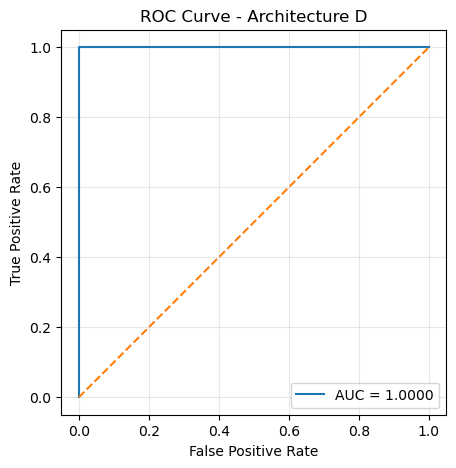

In [20]:
# D2: train and test architecture D
model_d = CNNClassifierD().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_d.parameters(), lr=1e-3)

print("Training CNNClassifierD...")
print("Trainable parameters:", count_trainable_parameters(model_d))

history_d = train_model(
    model=model_d,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
)

plot_training_history(history_d)

test_loss_d, test_f1_d, y_test_true_d, y_test_prob_d = evaluate_one_epoch(
    model=model_d,
    dataloader=test_loader,
    criterion=criterion,
)

print(f"Test loss (D): {test_loss_d:.4f}")
print(f"Test F1   (D): {test_f1_d:.4f}")

metrics_d = binary_classification_metrics(
    y_true=y_test_true_d,
    y_prob=y_test_prob_d,
    threshold=0.5,
    verbose=True,
)

plot_binary_roc(
    y_true=y_test_true_d,
    y_prob=y_test_prob_d,
    title="ROC Curve - Architecture D"
)

results_d = {
    "name": "Architecture D",
    "params": count_trainable_parameters(model_d),
    "val_f1_best": max(history_d["val_f1"]),
    "test_f1": metrics_d["f1"],
    "test_auc": metrics_d["roc_auc"],
}

In [21]:
all_results = [results_a, results_b, results_c, results_d]

print("Architectures:\n")
for res in all_results:
    print(
        f"{res['name']}: "
        f"params={res['params']}, "
        f"best_val_f1={res['val_f1_best']:.4f}, "
        f"test_f1={res['test_f1']:.4f}, "
        f"test_auc={res['test_auc']:.4f}"
    )

qualified = [res for res in all_results if res["test_f1"] > 0.9]

if len(qualified) > 0:
    smallest_qualified = min(qualified, key=lambda x: x["params"])
    print("\nSmallest tested model with test F1 > 0.9:")
    print(smallest_qualified)

Architectures:

Architecture A: params=529217, best_val_f1=1.0000, test_f1=1.0000, test_auc=1.0000
Architecture B: params=525601, best_val_f1=1.0000, test_f1=1.0000, test_auc=1.0000
Architecture C: params=270273, best_val_f1=1.0000, test_f1=1.0000, test_auc=1.0000
Architecture D: params=6433, best_val_f1=1.0000, test_f1=1.0000, test_auc=1.0000

Smallest tested model with test F1 > 0.9:
{'name': 'Architecture D', 'params': 6433, 'val_f1_best': 1.0, 'test_f1': 1.0, 'test_auc': 1.0}


The 2D adaptive average pooling layer compressed each channel to one average value (1, 1). This mostly reduced overfitting as our task did not require us to learn anything complex, like identify location of the particle... Which is why, I think, a global value was enough!

----------------------------------------------------------------------------------------------------------------------------------------

# 2. Multiclass Classification with hard_particle_dataset

Top-level object type: <class 'dict'>
Keys: ['images', 'labels']

Images:
  shape : (12000, 64, 64)
  dtype : float32
(N, H, W) = (number of images, height, width)

Labels:
  shape : (12000, 3)
  dtype : float32
labels (N, 3) where each row is [count, y, x]
[[ 3.        26.218569  22.573835 ]
 [ 3.        15.568533  19.242094 ]
 [ 0.         0.         0.       ]
 [ 0.         0.         0.       ]
 [ 5.        17.501247  22.955835 ]
 [ 3.        22.00986   27.266407 ]
 [ 1.        15.900332  26.70622  ]
 [ 2.         8.544725  16.547445 ]
 [ 1.         2.7399874  7.4186563]
 [ 0.         0.         0.       ]]

Column 0 = count label
  number of class 0 images: 2000
  number of class 1 images: 2000
  number of class 2 images: 2000
  number of class 3 images: 2000
  number of class 4 images: 2000
  number of class 5 images: 2000

Column 1 = y-position
  min: 0.0 max: 29.999872

Column 2 = x-position
  min: 0.0 max: 29.997145


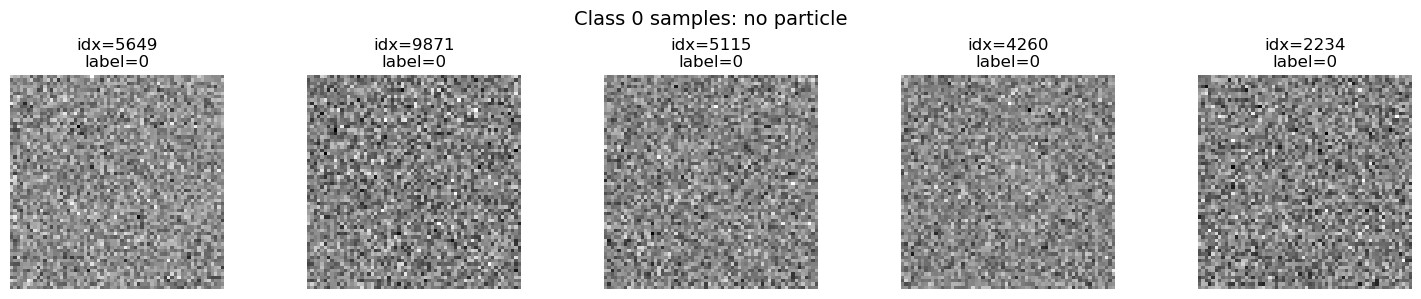

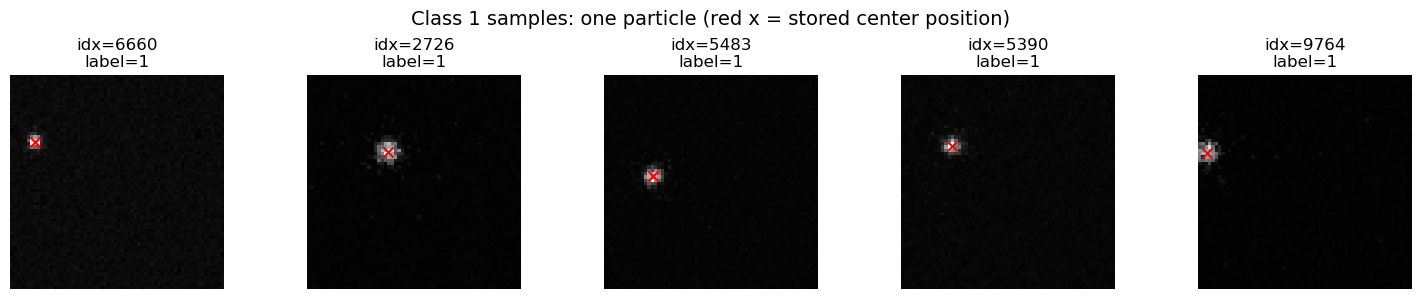

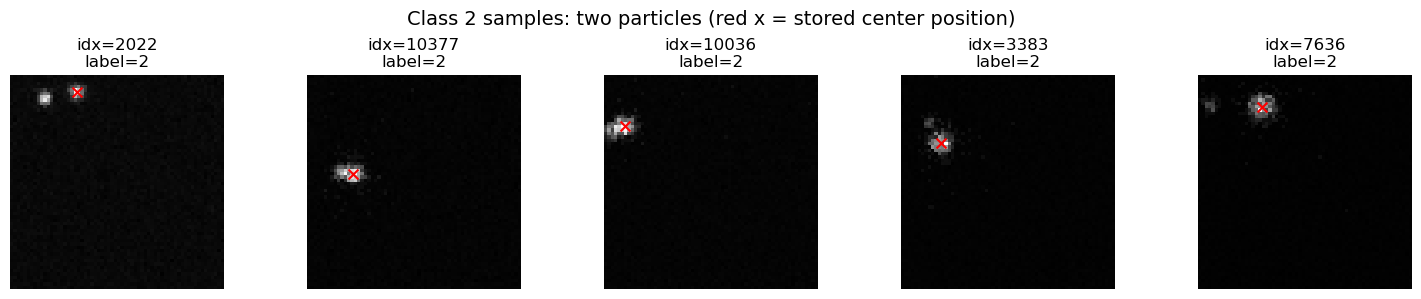

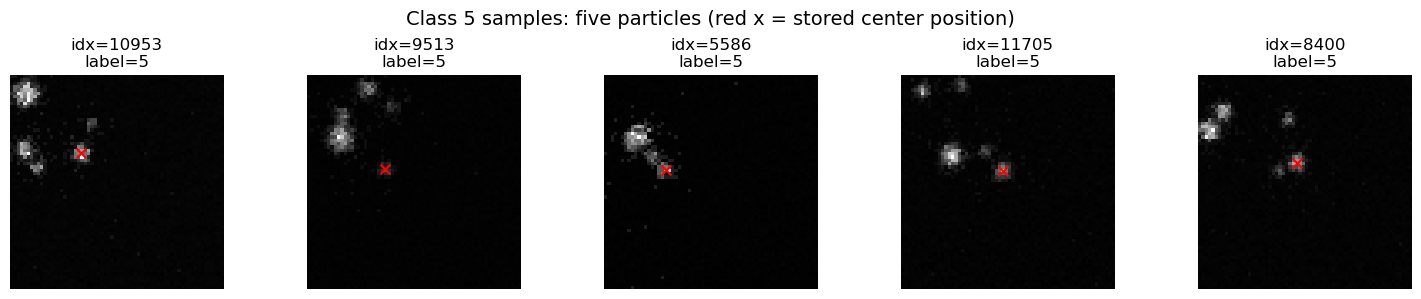

In [22]:
PKL_PATH = "hard_particle_dataset.pkl"
with open(PKL_PATH, "rb") as f:
    hard_data = pickle.load(f)

images = np.array(hard_data["images"], dtype=np.float32)
labels = np.array(hard_data["labels"], dtype=np.float32)

print("Top-level object type:", type(hard_data))
print("Keys:", list(hard_data.keys()))
print("\nImages:")
print("  shape :", images.shape)
print("  dtype :", images.dtype)
print("(N, H, W) = (number of images, height, width)")
print("\nLabels:")
print("  shape :", labels.shape)
print("  dtype :", labels.dtype)
print("labels (N, 3) where each row is [count, y, x]")
print(labels[:10])

count = labels[:, 0]
row_pos = labels[:, 1]   # y-position
col_pos = labels[:, 2]   # x-position
print("\nColumn 0 = count label")
for c in range(6):
    print(f"  number of class {c} images:", np.sum(count == c))
print("\nColumn 1 = y-position")
print("  min:", row_pos.min(), "max:", row_pos.max())
print("\nColumn 2 = x-position")
print("  min:", col_pos.min(), "max:", col_pos.max())

count = labels[:, 0].astype(int)
row_pos = labels[:, 1]   # vertical coordinate
col_pos = labels[:, 2]   # horizontal coordinate
n_show = 5

idx_0 = np.where(count == 0)[0]
idx_1 = np.where(count == 1)[0]
idx_2 = np.where(count == 2)[0]
idx_5 = np.where(count == 5)[0]
chosen_0 = rng.choice(idx_0, size=n_show, replace=False)
chosen_1 = rng.choice(idx_1, size=n_show, replace=False)
chosen_2 = rng.choice(idx_2, size=n_show, replace=False)
chosen_5 = rng.choice(idx_5, size=n_show, replace=False)

# class 0 sample no particle
plt.figure(figsize=(3 * n_show, 3))
for i, idx in enumerate(chosen_0):
    plt.subplot(1, n_show, i + 1)
    plt.imshow(images[idx], cmap="gray", origin="upper")
    plt.title(f"idx={idx}\nlabel=0")
    plt.axis("off")
plt.suptitle("Class 0 samples: no particle", fontsize=14)
plt.tight_layout()
plt.show()

# class 1 sample one particle
plt.figure(figsize=(3 * n_show, 3))
for i, idx in enumerate(chosen_1):
    plt.subplot(1, n_show, i + 1)
    plt.imshow(images[idx], cmap="gray", origin="upper")
    x = col_pos[idx]
    y = row_pos[idx]
    plt.scatter(x, y, c="red", s=50, marker="x", linewidths=1.5)
    plt.title(f"idx={idx}\nlabel=1")
    plt.axis("off")

plt.suptitle("Class 1 samples: one particle (red x = stored center position)", fontsize=14)
plt.tight_layout()
plt.show()

# class 2
plt.figure(figsize=(3 * n_show, 3))
for i, idx in enumerate(chosen_2):
    plt.subplot(1, n_show, i + 1)
    plt.imshow(images[idx], cmap="gray", origin="upper")
    x = col_pos[idx]
    y = row_pos[idx]
    plt.scatter(x, y, c="red", s=50, marker="x", linewidths=1.5)
    plt.title(f"idx={idx}\nlabel=2")
    plt.axis("off")

plt.suptitle("Class 2 samples: two particles (red x = stored center position)", fontsize=14)
plt.tight_layout()
plt.show()

# class 5
plt.figure(figsize=(3 * n_show, 3))
for i, idx in enumerate(chosen_5):
    plt.subplot(1, n_show, i + 1)
    plt.imshow(images[idx], cmap="gray", origin="upper")
    x = col_pos[idx]
    y = row_pos[idx]
    plt.scatter(x, y, c="red", s=50, marker="x", linewidths=1.5)
    plt.title(f"idx={idx}\nlabel=5")
    plt.axis("off")

plt.suptitle("Class 5 samples: five particles (red x = stored center position)", fontsize=14)
plt.tight_layout()
plt.show()

## Define a custom PyTorch Dataset for hard_particle_dataset

In [23]:
class HardParticleClassificationDataset(Dataset):
    def __init__(self, images, labels, indices=None):
        """
        images: numpy array of shape (N, 64, 64)
        labels: numpy array of shape (N, 3) with columns [count, y, x]
        """
        self.images = np.asarray(images, dtype=np.float32)
        self.labels = np.asarray(labels[:, 0], dtype=np.int64)  # only count label
        self.indices = np.arange(len(self.images)) if indices is None else np.asarray(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]

        image = self.images[idx]                       # full 64x64 image
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)  # (1, 64, 64)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

### Split data into train / validation / test

In [24]:
all_indices = np.arange(len(images))
all_targets = labels[:, 0].astype(np.int64)

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    stratify=all_targets,
    random_state=SEED,
)

temp_targets = all_targets[temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_targets,
    random_state=SEED,
)

print("Split sizes:")
print("Train:", len(train_idx))
print("Val  :", len(val_idx))
print("Test :", len(test_idx))

train_dataset = HardParticleClassificationDataset(images, labels, indices=train_idx)
val_dataset   = HardParticleClassificationDataset(images, labels, indices=val_idx)
test_dataset  = HardParticleClassificationDataset(images, labels, indices=test_idx)

def show_class_balance(indices, name):
    y = labels[indices, 0].astype(int)
    print(f"\n{name} class counts:")
    for c in sorted(np.unique(y)):
        print(f"Class {c}: {np.sum(y == c)}")

show_class_balance(train_idx, "Train")
show_class_balance(val_idx, "Val")
show_class_balance(test_idx, "Test")

Split sizes:
Train: 8400
Val  : 1800
Test : 1800

Train class counts:
Class 0: 1400
Class 1: 1400
Class 2: 1400
Class 3: 1400
Class 4: 1400
Class 5: 1400

Val class counts:
Class 0: 300
Class 1: 300
Class 2: 300
Class 3: 300
Class 4: 300
Class 5: 300

Test class counts:
Class 0: 300
Class 1: 300
Class 2: 300
Class 3: 300
Class 4: 300
Class 5: 300


### Create dataloaders for train / validation / test

In [25]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print("Number of batches:")
print("Train loader:", len(train_loader))
print("Val loader  :", len(val_loader))
print("Test loader :", len(test_loader))

batch_images, batch_labels = next(iter(train_loader))
print("\nOne training batch:")
print("batch_images shape:", batch_images.shape)
print("batch_images dtype:", batch_images.dtype)
print("batch_labels shape:", batch_labels.shape)
print("batch_labels dtype:", batch_labels.dtype)
print("First 10 labels:", batch_labels[:10].numpy())

Number of batches:
Train loader: 132
Val loader  : 29
Test loader : 29

One training batch:
batch_images shape: torch.Size([64, 1, 64, 64])
batch_images dtype: torch.float32
batch_labels shape: torch.Size([64])
batch_labels dtype: torch.int64
First 10 labels: [1 5 0 5 0 5 2 0 1 5]


## Define multiclass CNN architectures (A2, D2, E2)

In [26]:
class CNNClassifierA2(nn.Module):
    # Q1-A style model, adapted to 6 classes
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -- 32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -- 16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class CNNClassifierD2(nn.Module):
    # Q1-D style compact model, adapted to 6 classes
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -- 32

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -- 16

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print("A2 params:", count_trainable_parameters(CNNClassifierA2()))
print("D2 params:", count_trainable_parameters(CNNClassifierD2()))

model_a = CNNClassifierA2()
print("\n",model_a)
model_d = CNNClassifierD2()
print("\n",model_d)

A2 params: 529542
D2 params: 6518

 CNNClassifierA2(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=6, bias=True)
  )
)

 CNNClassifierD2(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, pad

## Multiclass training and evaluation loops

In [27]:
NUM_EPOCHS_BASELINE = 100
criterion_ce = nn.CrossEntropyLoss()


def multiclass_classification_metrics(y_true, y_pred, verbose=True):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    cm = confusion_matrix(y_true, y_pred)

    metrics = {
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "confusion_matrix": cm,
    }

    if verbose:
        print(f"Macro F1   : {macro_f1:.4f}")
        print(f"Weighted F1: {weighted_f1:.4f}")
        print("Confusion matrix:")
        print(cm)
        print("\nClassification report:")
        print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    return metrics


def plot_multiclass_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.colorbar()

    n_classes = cm.shape[0]
    for i in range(n_classes):
        for j in range(n_classes):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    plt.xticks(range(n_classes))
    plt.yticks(range(n_classes))
    plt.tight_layout()
    plt.show()


def train_one_epoch_multiclass(model, dataloader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_images, batch_labels in dataloader:
        batch_images = batch_images.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        optimizer.zero_grad()
        batch_logits = model(batch_images)
        loss = criterion(batch_logits, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_images.size(0)

        batch_preds = torch.argmax(batch_logits, dim=1)
        all_preds.extend(batch_preds.detach().cpu().numpy())
        all_labels.extend(batch_labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_macro_f1 = f1_score(np.array(all_labels), np.array(all_preds), average="macro")
    return epoch_loss, epoch_macro_f1


def evaluate_one_epoch_multiclass(model, dataloader, criterion):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_images, batch_labels in dataloader:
            batch_images = batch_images.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)

            batch_logits = model(batch_images)
            loss = criterion(batch_logits, batch_labels)

            running_loss += loss.item() * batch_images.size(0)

            batch_preds = torch.argmax(batch_logits, dim=1)
            all_preds.extend(batch_preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_macro_f1 = f1_score(np.array(all_labels), np.array(all_preds), average="macro")
    return epoch_loss, epoch_macro_f1, np.array(all_labels), np.array(all_preds)


def train_model_multiclass(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS_BASELINE):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_f1": [],
        "val_f1": [],
    }

    best_val_f1 = -1.0
    best_state_dict = None

    for epoch in range(num_epochs):
        train_loss, train_f1 = train_one_epoch_multiclass(model, train_loader, criterion, optimizer)
        val_loss, val_f1, _, _ = evaluate_one_epoch_multiclass(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_macro_f1={train_f1:.4f} | val_macro_f1={val_f1:.4f}"
        )

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    print(f"\nBest validation macro F1: {best_val_f1:.4f}")
    return history


def run_multiclass_experiment(model_class, model_name, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS_BASELINE):
    model = model_class().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    print(f"\nTraining {model_name}...")
    print("Trainable parameters:", count_trainable_parameters(model))

    history = train_model_multiclass(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_ce,
        optimizer=optimizer,
        num_epochs=num_epochs,
    )

    plot_training_history(history)

    test_loss, test_macro_f1, y_true, y_pred = evaluate_one_epoch_multiclass(
        model=model,
        dataloader=test_loader,
        criterion=criterion_ce,
    )

    print(f"Test loss ({model_name}): {test_loss:.4f}")
    print(f"Test macro F1 ({model_name}): {test_macro_f1:.4f}")

    metrics = multiclass_classification_metrics(y_true=y_true, y_pred=y_pred, verbose=True)
    plot_multiclass_confusion_matrix(metrics["confusion_matrix"], title=f"Confusion Matrix - {model_name}")

    results = {
        "name": model_name,
        "params": count_trainable_parameters(model),
        "val_f1_best": max(history["val_f1"]),
        "test_macro_f1": metrics["macro_f1"],
        "test_weighted_f1": metrics["weighted_f1"],
    }

    return model, history, metrics, results


Training Architecture A2...
Trainable parameters: 529542
Epoch 01/100 | train_loss=2.9278 | val_loss=1.7927 | train_macro_f1=0.1107 | val_macro_f1=0.0802
Epoch 02/100 | train_loss=1.7929 | val_loss=1.7923 | train_macro_f1=0.1243 | val_macro_f1=0.0871
Epoch 03/100 | train_loss=1.7923 | val_loss=1.7922 | train_macro_f1=0.1160 | val_macro_f1=0.0863
Epoch 04/100 | train_loss=1.7924 | val_loss=1.7916 | train_macro_f1=0.1056 | val_macro_f1=0.0866
Epoch 05/100 | train_loss=1.7936 | val_loss=1.7898 | train_macro_f1=0.1105 | val_macro_f1=0.1291
Epoch 06/100 | train_loss=1.8196 | val_loss=1.7916 | train_macro_f1=0.1294 | val_macro_f1=0.0866
Epoch 07/100 | train_loss=1.7922 | val_loss=1.7915 | train_macro_f1=0.1189 | val_macro_f1=0.1184
Epoch 08/100 | train_loss=1.7918 | val_loss=1.7914 | train_macro_f1=0.1111 | val_macro_f1=0.0831
Epoch 09/100 | train_loss=1.7918 | val_loss=1.7913 | train_macro_f1=0.0931 | val_macro_f1=0.0864
Epoch 10/100 | train_loss=1.7916 | val_loss=1.7910 | train_macro_f1=0

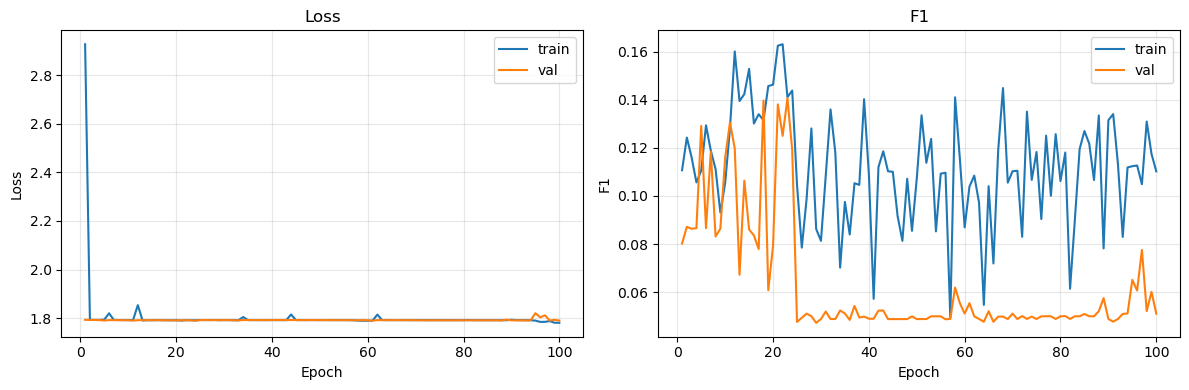

Test loss (Architecture A2): 1.7924
Test macro F1 (Architecture A2): 0.1295
Macro F1   : 0.1295
Weighted F1: 0.1295
Confusion matrix:
[[  5  92  72   0  80  51]
 [  0  84  76   0  84  56]
 [  4  94  69   0  72  61]
 [  5  88  73   0  77  57]
 [  1 102  77   0  71  49]
 [  4 106  62   0  73  55]]

Classification report:
              precision    recall  f1-score   support

           0     0.2632    0.0167    0.0313       300
           1     0.1484    0.2800    0.1940       300
           2     0.1608    0.2300    0.1893       300
           3     0.0000    0.0000    0.0000       300
           4     0.1554    0.2367    0.1876       300
           5     0.1672    0.1833    0.1749       300

    accuracy                         0.1578      1800
   macro avg     0.1492    0.1578    0.1295      1800
weighted avg     0.1492    0.1578    0.1295      1800



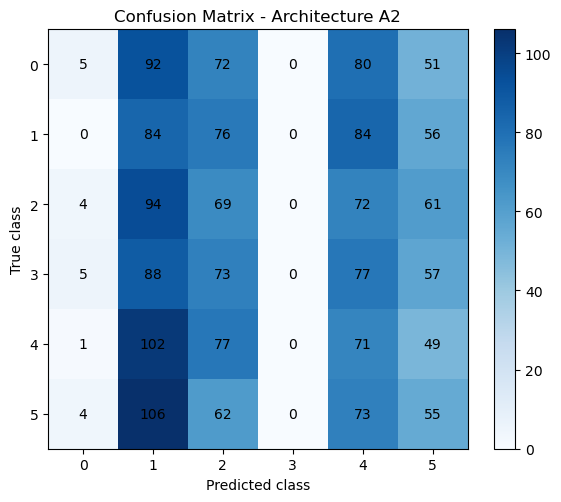

In [28]:
model_a2, history_a2, metrics_a2, results_a2 = run_multiclass_experiment(
    model_class=CNNClassifierA2,
    model_name="Architecture A2",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS_BASELINE,
)


Training Architecture D2...
Trainable parameters: 6518
Epoch 01/100 | train_loss=1.8707 | val_loss=1.7959 | train_macro_f1=0.0795 | val_macro_f1=0.0476
Epoch 02/100 | train_loss=1.7955 | val_loss=1.7935 | train_macro_f1=0.0840 | val_macro_f1=0.0476
Epoch 03/100 | train_loss=1.7931 | val_loss=1.7924 | train_macro_f1=0.0513 | val_macro_f1=0.0475
Epoch 04/100 | train_loss=1.7923 | val_loss=1.7920 | train_macro_f1=0.0486 | val_macro_f1=0.0474
Epoch 05/100 | train_loss=1.7921 | val_loss=1.7918 | train_macro_f1=0.1071 | val_macro_f1=0.0690
Epoch 06/100 | train_loss=1.7919 | val_loss=1.7918 | train_macro_f1=0.0830 | val_macro_f1=0.0612
Epoch 07/100 | train_loss=1.7918 | val_loss=1.7917 | train_macro_f1=0.0699 | val_macro_f1=0.0589
Epoch 08/100 | train_loss=1.7917 | val_loss=1.7916 | train_macro_f1=0.1229 | val_macro_f1=0.0717
Epoch 09/100 | train_loss=1.7917 | val_loss=1.7916 | train_macro_f1=0.0980 | val_macro_f1=0.0620
Epoch 10/100 | train_loss=1.7950 | val_loss=1.7918 | train_macro_f1=0.1

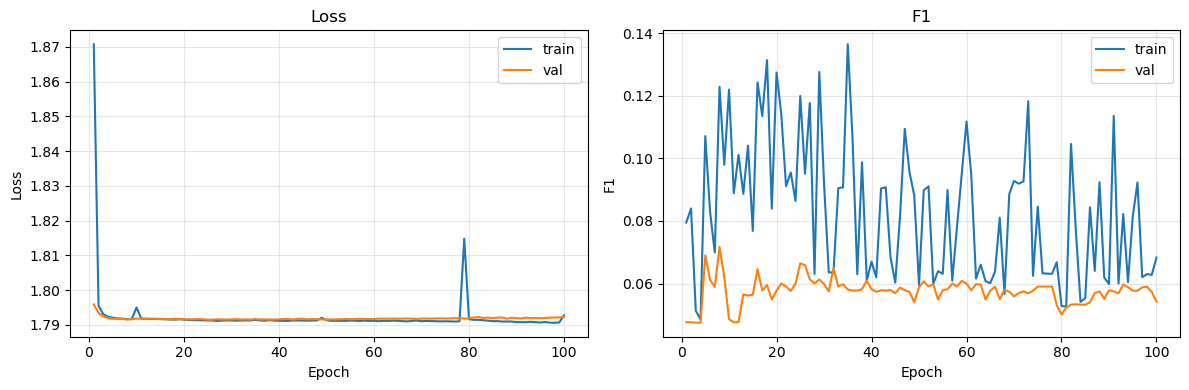

Test loss (Architecture D2): 1.7922
Test macro F1 (Architecture D2): 0.0725
Macro F1   : 0.0725
Weighted F1: 0.0725
Confusion matrix:
[[  2   0   0   0 263  35]
 [  0   0   5   0 261  34]
 [  3   0   1   0 265  31]
 [  4   0   2   0 262  32]
 [  1   0   1   0 266  32]
 [  1   0   1   0 265  33]]

Classification report:
              precision    recall  f1-score   support

           0     0.1818    0.0067    0.0129       300
           1     0.0000    0.0000    0.0000       300
           2     0.1000    0.0033    0.0065       300
           3     0.0000    0.0000    0.0000       300
           4     0.1681    0.8867    0.2827       300
           5     0.1675    0.1100    0.1328       300

    accuracy                         0.1678      1800
   macro avg     0.1029    0.1678    0.0725      1800
weighted avg     0.1029    0.1678    0.0725      1800



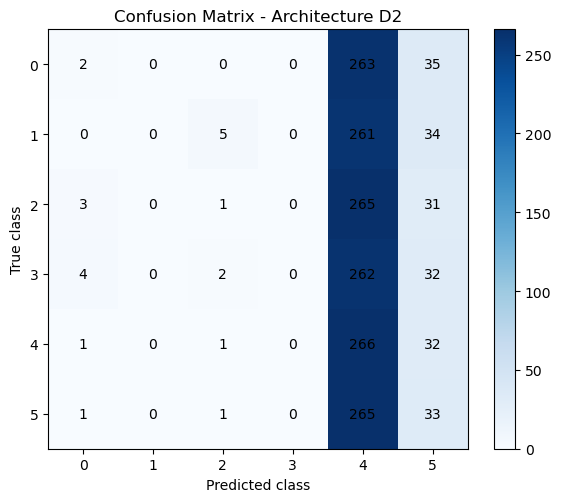

In [29]:
model_d2, history_d2, metrics_d2, results_d2 = run_multiclass_experiment(
    model_class=CNNClassifierD2,
    model_name="Architecture D2",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS_BASELINE,
)

In [30]:
# ordinal CNN
class OrdinalCNNQ2_E2(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -- 32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -- 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16 -- 8
        )

        self.backbone_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(),
        )

        # CORAL-style shared-weight ordinal head:
        # one shared score + (K-1) learned biases
        self.ordinal_fc = nn.Linear(128, 1, bias=False)
        self.ordinal_bias = nn.Parameter(torch.zeros(num_classes - 1))

    def forward(self, x):
        x = self.features(x)
        x = self.backbone_head(x)
        shared_logit = self.ordinal_fc(x)              # (B, 1)
        logits = shared_logit + self.ordinal_bias      # (B, 5)
        return logits


print("E2 params:", count_trainable_parameters(OrdinalCNNQ2_E2()))
model_e = OrdinalCNNQ2_E2()
print("\n",model_e)

E2 params: 1146245

 OrdinalCNNQ2_E2(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (backbone_head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
  )
  (ordinal_fc): Linear(in_features=128, out_features=1, bias=False)
)


In [31]:
# ordinal helpers, weighted loss, and threshold tuning
NUM_EPOCHS_E2 = 100

def counts_to_ordinal_targets(y, num_classes=6):
    """
    Convert labels 0..5 into 5 threshold targets:
    0 -- [0,0,0,0,0]
    1 -- [1,0,0,0,0]
    2 -- [1,1,0,0,0]
    ...
    5 -- [1,1,1,1,1]
    """
    y = y.cpu().numpy().astype(int)
    out = np.zeros((len(y), num_classes - 1), dtype=np.float32)
    for i, label in enumerate(y):
        out[i, :label] = 1.0
    return torch.tensor(out, dtype=torch.float32)


def compute_ordinal_pos_weight(train_count_labels, num_classes=6):
    """
    One pos_weight per threshold task:
    y > 0, y > 1, ..., y > 4
    """
    y = np.asarray(train_count_labels).astype(int)
    ordinal_targets = np.stack([(y > k).astype(np.float32) for k in range(num_classes - 1)], axis=1)

    pos = ordinal_targets.sum(axis=0)
    neg = len(y) - pos
    pos_weight = neg / np.maximum(pos, 1.0)
    return torch.tensor(pos_weight, dtype=torch.float32)


train_count_labels = labels[train_idx, 0].astype(np.int64)
ordinal_pos_weight = compute_ordinal_pos_weight(train_count_labels, num_classes=6)
print("Ordinal pos_weight:", ordinal_pos_weight)


def ordinal_logits_to_class(pred_logits, thresholds=0.5):
    probs = torch.sigmoid(pred_logits)

    if np.isscalar(thresholds):
        thresholds = torch.full((probs.shape[1],), float(thresholds), dtype=probs.dtype, device=probs.device)
    else:
        thresholds = torch.tensor(thresholds, dtype=probs.dtype, device=probs.device)

    preds = (probs >= thresholds.unsqueeze(0)).sum(dim=1)
    return preds


def find_best_thresholds_per_level(model, dataloader):
    model.eval()

    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch_images, batch_labels in dataloader:
            batch_images = batch_images.to(DEVICE)
            batch_logits = model(batch_images)

            all_logits.append(batch_logits.cpu())
            all_labels.append(batch_labels.cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0).numpy()

    probs = torch.sigmoid(all_logits).numpy()

    best_thresholds = []
    for k in range(probs.shape[1]):
        true_bin = (all_labels > k).astype(int)

        best_t = 0.5
        best_f1 = -1.0

        for t in np.linspace(0.20, 0.80, 61):
            pred_bin = (probs[:, k] >= t).astype(int)
            f1 = f1_score(true_bin, pred_bin, average="binary", zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = float(t)

        best_thresholds.append(best_t)

    best_thresholds = np.array(best_thresholds)

    val_preds = ordinal_logits_to_class(all_logits, thresholds=best_thresholds).numpy()
    val_macro_f1 = f1_score(all_labels, val_preds, average="macro")

    return best_thresholds, val_macro_f1


def train_one_epoch_ordinal(model, dataloader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch_images, batch_labels in dataloader:
        batch_images = batch_images.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        batch_targets = counts_to_ordinal_targets(batch_labels).to(DEVICE)

        optimizer.zero_grad()
        batch_logits = model(batch_images)
        loss = criterion(batch_logits, batch_targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_images.size(0)

        batch_preds = ordinal_logits_to_class(batch_logits, thresholds=0.5)
        all_preds.extend(batch_preds.detach().cpu().numpy())
        all_labels.extend(batch_labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_macro_f1 = f1_score(np.array(all_labels), np.array(all_preds), average="macro")
    return epoch_loss, epoch_macro_f1


def evaluate_one_epoch_ordinal(model, dataloader, criterion, thresholds=0.5):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_images, batch_labels in dataloader:
            batch_images = batch_images.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)

            batch_targets = counts_to_ordinal_targets(batch_labels).to(DEVICE)

            batch_logits = model(batch_images)
            loss = criterion(batch_logits, batch_targets)

            running_loss += loss.item() * batch_images.size(0)

            batch_preds = ordinal_logits_to_class(batch_logits, thresholds=thresholds)
            all_preds.extend(batch_preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_macro_f1 = f1_score(np.array(all_labels), np.array(all_preds), average="macro")
    return epoch_loss, epoch_macro_f1, np.array(all_labels), np.array(all_preds)


def train_model_ordinal(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS_E2):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_f1": [],
        "val_f1": [],
    }

    best_val_f1 = -1.0
    best_state_dict = None

    for epoch in range(num_epochs):
        train_loss, train_f1 = train_one_epoch_ordinal(model, train_loader, criterion, optimizer)
        val_loss, val_f1, _, _ = evaluate_one_epoch_ordinal(model, val_loader, criterion, thresholds=0.5)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_macro_f1={train_f1:.4f} | val_macro_f1={val_f1:.4f}"
        )

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    print(f"\nBest validation macro F1 (0.5 thresholds): {best_val_f1:.4f}")
    return history


def run_ordinal_experiment(model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS_E2):
    criterion_ord = nn.BCEWithLogitsLoss(pos_weight=ordinal_pos_weight.to(DEVICE))
    optimizer_ord = torch.optim.Adam(model.parameters(), lr=3e-4)

    history = train_model_ordinal(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_ord,
        optimizer=optimizer_ord,
        num_epochs=num_epochs,
    )

    plot_training_history(history)

    best_thresholds, best_val_macro_f1_thresholded = find_best_thresholds_per_level(
        model=model,
        dataloader=val_loader,
    )

    print("Best per-level thresholds:", best_thresholds)
    print(f"Validation macro F1 with tuned thresholds: {best_val_macro_f1_thresholded:.4f}")

    test_loss, test_macro_f1, y_true, y_pred = evaluate_one_epoch_ordinal(
        model=model,
        dataloader=test_loader,
        criterion=criterion_ord,
        thresholds=best_thresholds,
    )

    print(f"Test loss: {test_loss:.4f}")
    print(f"Test macro F1: {test_macro_f1:.4f}")

    metrics = multiclass_classification_metrics(y_true=y_true, y_pred=y_pred, verbose=True)
    plot_multiclass_confusion_matrix(metrics["confusion_matrix"], title="Confusion Matrix - E2")

    results = {
        "name": "Architecture E2",
        "params": count_trainable_parameters(model),
        "val_f1_best_default05": max(history["val_f1"]),
        "val_f1_best_tuned": best_val_macro_f1_thresholded,
        "test_macro_f1": metrics["macro_f1"],
        "test_weighted_f1": metrics["weighted_f1"],
    }

    return history, metrics, best_thresholds, results

Ordinal pos_weight: tensor([0.2000, 0.5000, 1.0000, 2.0000, 5.0000])


Epoch 01/100 | train_loss=0.6970 | val_loss=0.6225 | train_macro_f1=0.1162 | val_macro_f1=0.1323
Epoch 02/100 | train_loss=0.5677 | val_loss=0.5342 | train_macro_f1=0.1658 | val_macro_f1=0.1759
Epoch 03/100 | train_loss=0.5502 | val_loss=0.5373 | train_macro_f1=0.1800 | val_macro_f1=0.2105
Epoch 04/100 | train_loss=0.5299 | val_loss=0.5085 | train_macro_f1=0.1853 | val_macro_f1=0.1933
Epoch 05/100 | train_loss=0.5199 | val_loss=0.5322 | train_macro_f1=0.1926 | val_macro_f1=0.1981
Epoch 06/100 | train_loss=0.5054 | val_loss=0.4623 | train_macro_f1=0.1976 | val_macro_f1=0.1978
Epoch 07/100 | train_loss=0.4731 | val_loss=0.4948 | train_macro_f1=0.1993 | val_macro_f1=0.2087
Epoch 08/100 | train_loss=0.4500 | val_loss=0.3947 | train_macro_f1=0.2101 | val_macro_f1=0.2150
Epoch 09/100 | train_loss=0.3974 | val_loss=0.3767 | train_macro_f1=0.2192 | val_macro_f1=0.2075
Epoch 10/100 | train_loss=0.3838 | val_loss=0.3770 | train_macro_f1=0.2235 | val_macro_f1=0.2207
Epoch 11/100 | train_loss=0.35

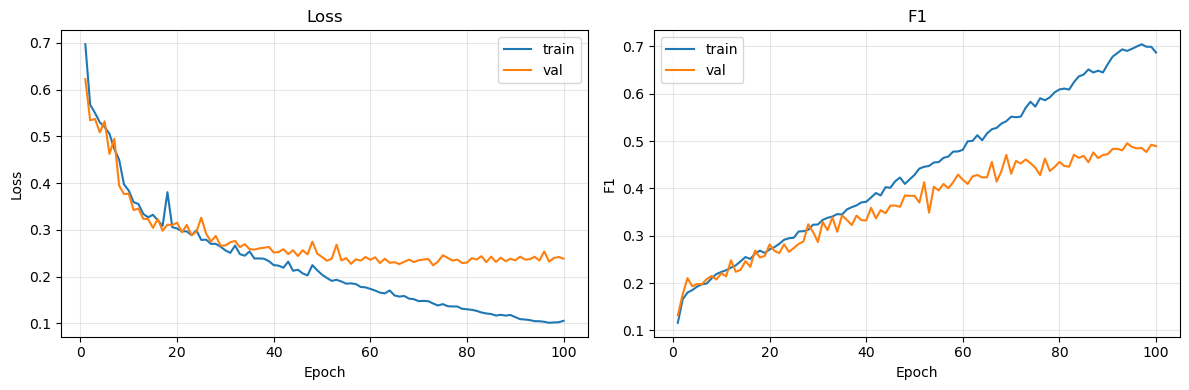

Best per-level thresholds: [0.2  0.34 0.46 0.62 0.76]
Validation macro F1 with tuned thresholds: 0.6834
Test loss: 0.2335
Test macro F1: 0.6736
Macro F1   : 0.6736
Weighted F1: 0.6736
Confusion matrix:
[[300   0   0   0   0   0]
 [121 169  10   0   0   0]
 [  4  29 235  32   0   0]
 [  1   3  47 170  76   3]
 [  0   0  15  63 140  82]
 [  0   0   1  12  77 210]]

Classification report:
              precision    recall  f1-score   support

           0     0.7042    1.0000    0.8264       300
           1     0.8408    0.5633    0.6747       300
           2     0.7630    0.7833    0.7730       300
           3     0.6137    0.5667    0.5893       300
           4     0.4778    0.4667    0.4722       300
           5     0.7119    0.7000    0.7059       300

    accuracy                         0.6800      1800
   macro avg     0.6852    0.6800    0.6736      1800
weighted avg     0.6852    0.6800    0.6736      1800



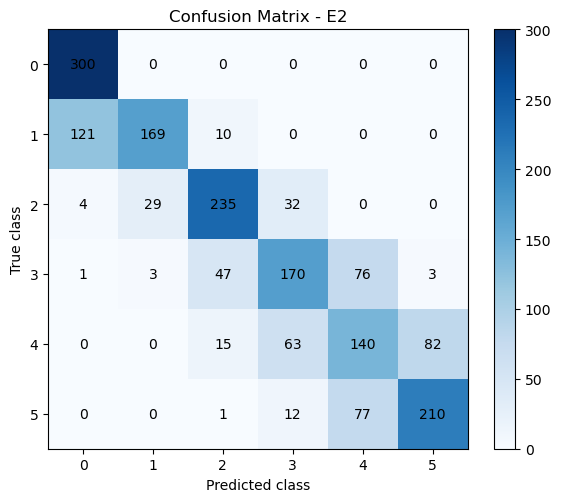

In [32]:
model_j2 = OrdinalCNNQ2_E2().to(DEVICE)
history_j2, metrics_j2, best_thresholds_j2, results_j2 = run_ordinal_experiment(
    model=model_j2,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS_E2,
)

In [33]:
all_results_q2 = [results_a2, results_d2, results_j2]

print("Architecture comparison for Q2:\n")
for res in all_results_q2:
    if res["name"] == "Architecture E2":
        print(
            f"{res['name']}: "
            f"params={res['params']}, "
            f"best_val_macro_f1_default05={res['val_f1_best_default05']:.4f}, "
            f"best_val_macro_f1_tuned={res['val_f1_best_tuned']:.4f}, "
            f"test_macro_f1={res['test_macro_f1']:.4f}, "
            f"test_weighted_f1={res['test_weighted_f1']:.4f}"
        )
    else:
        print(
            f"{res['name']}: "
            f"params={res['params']}, "
            f"best_val_macro_f1={res['val_f1_best']:.4f}, "
            f"test_macro_f1={res['test_macro_f1']:.4f}, "
            f"test_weighted_f1={res['test_weighted_f1']:.4f}"
        )

qualified = [res for res in all_results_q2 if res["test_macro_f1"] > 0.9]

if len(qualified) > 0:
    most_efficient = min(qualified, key=lambda x: x["params"])
    print("\nMost efficient architecture with test macro F1 > 0.9:")
    print(most_efficient)
else:
    print("\nNo tested architecture achieved test macro F1 > 0.9.")

Architecture comparison for Q2:

Architecture A2: params=529542, best_val_macro_f1=0.1407, test_macro_f1=0.1295, test_weighted_f1=0.1295
Architecture D2: params=6518, best_val_macro_f1=0.0717, test_macro_f1=0.0725, test_weighted_f1=0.0725
Architecture E2: params=1146245, best_val_macro_f1_default05=0.4952, best_val_macro_f1_tuned=0.6834, test_macro_f1=0.6736, test_weighted_f1=0.6736

No tested architecture achieved test macro F1 > 0.9.


A2 and D2 were straightforward multiclass extensions of the Q1 CNNs, but they failed on the hard dataset. E2 worked better because the target was not just “which class,” but an ordered particle count, so an ordinal model with weighted threshold losses and tuned decoding thresholds matched the structure of the problem better. Even then, the best test macro F1 was 0.6736, so the assignment target of F1 > 0.9 was not reached with the tested architectures.

----------------------------------------------------------------------------------------------------------------------------------------------------

# 3. Particle Localization on simple dataset

## Load and prune the dataset

In [34]:
with open("simple_particle_dataset.pkl", "rb") as f:
    simple_data = pickle.load(f)

images = np.array(simple_data["images"], dtype=np.float32)
labels = np.array(simple_data["labels"], dtype=np.float32)

print(images.shape)   # (N, 64, 64)
print(labels.shape)   # (N, 3) = [count, y, x]
print(labels[:5])

(10000, 64, 64)
(10000, 3)
[[ 1.       24.87655  11.326707]
 [ 1.       27.13841   8.074459]
 [ 0.        0.        0.      ]
 [ 0.        0.        0.      ]
 [ 1.       18.114408  8.362782]]


Original: 10000
After pruning: 5000


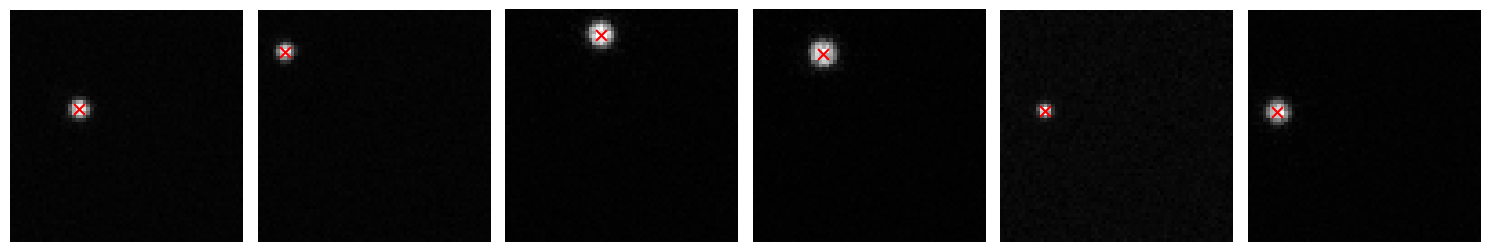

In [35]:
mask = labels[:, 0] == 1
images_loc = images[mask]
coords_px = labels[mask][:, 1:3]   # [y, x]
print("Original:", len(images))
print("After pruning:", len(images_loc))

idx = np.random.choice(len(images_loc), size=6, replace=False)
plt.figure(figsize=(15, 3))
for i, j in enumerate(idx):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images_loc[j], cmap="gray", origin="upper")
    y, x = coords_px[j]
    plt.scatter(x, y, c="r", marker="x", s=60)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Normalize coordinates and build the regression dataset

In [36]:
H, W = images_loc.shape[1], images_loc.shape[2]
coords = coords_px.copy()
coords[:, 0] = coords[:, 0] / (H - 1)
coords[:, 1] = coords[:, 1] / (W - 1)

class SimpleParticleLocalizationDataset(Dataset):
    def __init__(self, images, coords):
        self.images = images.astype(np.float32)
        self.coords = coords.astype(np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32).unsqueeze(0)
        target = torch.tensor(self.coords[idx], dtype=torch.float32)  # [y, x]
        return image, target

full_dataset = SimpleParticleLocalizationDataset(images_loc, coords)

## Train/validation/test split

In [37]:
n_total = len(full_dataset)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

In [38]:
# dataloaders for train / val / test
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [39]:
def mae_in_pixels(pred, target, H=64, W=64):
    pred_px = pred.clone()
    target_px = target.clone()

    pred_px[:, 0] *= (H - 1)
    pred_px[:, 1] *= (W - 1)
    target_px[:, 0] *= (H - 1)
    target_px[:, 1] *= (W - 1)

    return (pred_px - target_px).abs().mean().item()

## Localization models

In [40]:
# classification-like baseline
class LocNetA(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64), nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.head(self.features(x))


# localization-aware medium model
class LocNetB(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 5, padding=2), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128), nn.ReLU(),
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.head(self.features(x))


# tiny candidate for smallest network
class LocNetC(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 16 * 16, 32), nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.head(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Training and evaluation

In [41]:
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    mse_meter = 0.0
    mae_px_meter = 0.0
    n = 0

    criterion = nn.SmoothL1Loss(beta=0.5)

    for images, targets in loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        with torch.set_grad_enabled(training):
            preds = model(images)
            loss = criterion(preds, targets)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        batch_size = images.size(0)
        mse_meter += loss.item() * batch_size
        mae_px_meter += mae_in_pixels(preds.detach().cpu(), targets.detach().cpu()) * batch_size
        n += batch_size

    return mse_meter / n, mae_px_meter / n

## Search for smaller successful model (test MAE < 1 pixel)

In [42]:
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3, patience=5):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_val = float("inf")
    wait = 0
    history = []

    for epoch in range(epochs):
        train_mse, train_mae = run_epoch(model, train_loader, optimizer)
        val_mse, val_mae = run_epoch(model, val_loader)

        history.append((train_mse, train_mae, val_mse, val_mae))

        if val_mae < best_val:
            best_val = val_mae
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, history

In [43]:
class LocNetD(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 4, 5, padding=2), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(4, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 16 * 16, 8), nn.ReLU(),
            nn.Linear(8, 2)
        )

    def forward(self, x):
        return self.head(self.features(x))

In [44]:
models = {
    "LocNetA": LocNetA(),
    "LocNetB": LocNetB(),
    "LocNetC": LocNetC(),
    "LocNetD": LocNetD(),
}

results = []
histories = {}
trained_models = {}

for name, model in models.items():
    trained_model, history = train_model(
        model, train_loader, val_loader,
        epochs=40, lr=1e-3, patience=6
    )
    test_mse, test_mae_px = run_epoch(trained_model, test_loader)

    trained_models[name] = trained_model
    histories[name] = history

    results.append({
        "model": name,
        "params": count_params(trained_model),
        "test_mse": test_mse,
        "test_mae_px": test_mae_px,
    })

results

[{'model': 'LocNetA',
  'params': 529282,
  'test_mse': 2.3780563807425398e-05,
  'test_mae_px': 0.22017067909240723},
 {'model': 'LocNetB',
  'params': 2125026,
  'test_mse': 8.628189370938343e-06,
  'test_mae_px': 0.1303117240269979},
 {'model': 'LocNetC',
  'params': 132418,
  'test_mse': 1.5872083536426847e-05,
  'test_mae_px': 0.1846225042740504},
 {'model': 'LocNetD',
  'params': 16810,
  'test_mse': 3.267936555979153e-05,
  'test_mae_px': 0.2581737786928813}]

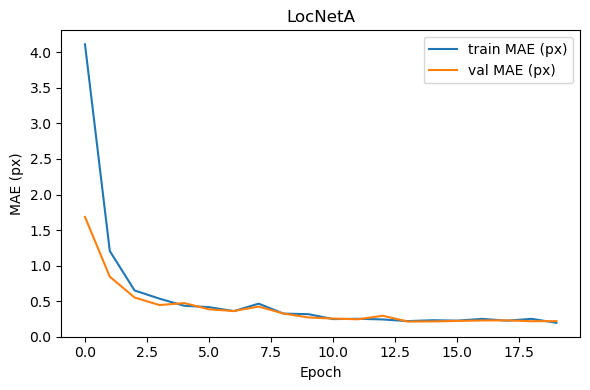

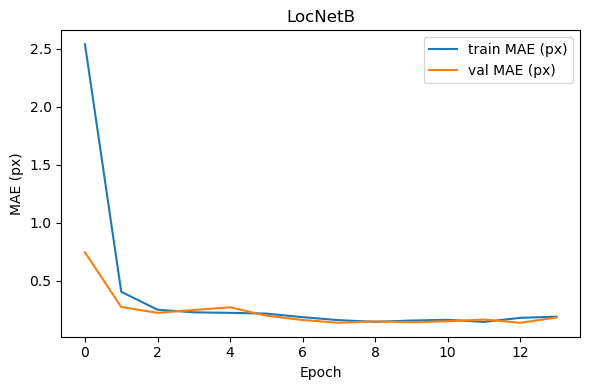

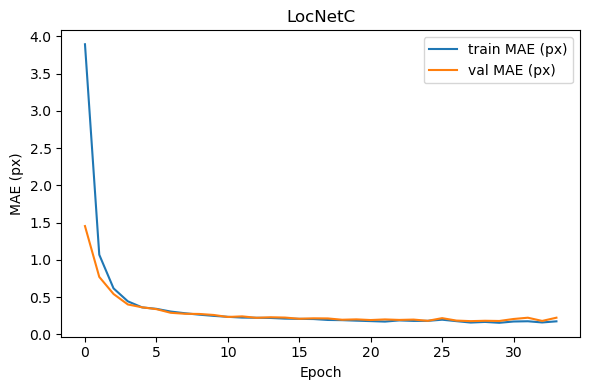

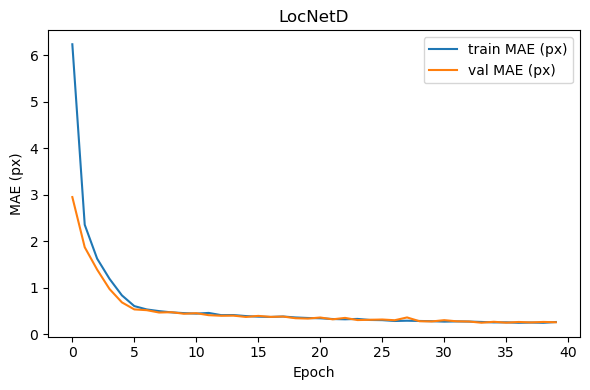

In [45]:
def plot_history(history, title=""):
    history = np.array(history)
    plt.figure(figsize=(6, 4))
    plt.plot(history[:, 1], label="train MAE (px)")
    plt.plot(history[:, 3], label="val MAE (px)")
    plt.xlabel("Epoch")
    plt.ylabel("MAE (px)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

for name in histories:
    plot_history(histories[name], title=name)

In [46]:
results_df = pd.DataFrame(results).sort_values(["test_mae_px", "params"])
display(results_df)

below_1px = results_df[results_df["test_mae_px"] < 1.0].sort_values("params")
display(below_1px)

smallest_success = below_1px.iloc[0]
print("Smallest tested model with test MAE < 1 pixel:")
print(smallest_success)

,model,params,test_mse,test_mae_px
1,LocNetB,2125026,0.000009,0.130312
2,LocNetC,132418,0.000016,0.184623
0,LocNetA,529282,0.000024,0.220171
3,LocNetD,16810,0.000033,0.258174


,model,params,test_mse,test_mae_px
3,LocNetD,16810,0.000033,0.258174
2,LocNetC,132418,0.000016,0.184623
0,LocNetA,529282,0.000024,0.220171
1,LocNetB,2125026,0.000009,0.130312


Smallest tested model with test MAE < 1 pixel:
model           LocNetD
params            16810
test_mse       0.000033
test_mae_px    0.258174
Name: 3, dtype: object



-----------------------------------------------------------------------------------------------------------------------------------------------------

The zero-particle images were removed before training, reducing the dataset from 10,000 to 5,000 samples.  
The task was formulated as coordinate regression with two outputs corresponding to the particle position.  
Three CNN architectures (LocNetA, LocNetB, and LocNetC) were compared using mean absolute error on the test set, and all achieved test MAE below 1 pixel.  
An additional smaller architecture, LocNetD, was then tested to search for a smaller successful network.  
Among the tested models, LocNetD was the smallest network that still achieved test MAE below 1 pixel.

-----------------------------------------------------------------------------------------------------------------------------------------------------

# 3. Particle Localization on hard dataset

In [47]:
with open("hard_particle_dataset.pkl", "rb") as f:
    hard_data = pickle.load(f)

images = np.array(hard_data["images"], dtype=np.float32)
labels = np.array(hard_data["labels"], dtype=np.float32)

print(images.shape)   # (12000, 64, 64)
print(labels.shape)   # (12000, 3) = [count, y, x]
print(labels[:5])

(12000, 64, 64)
(12000, 3)
[[ 3.       26.218569 22.573835]
 [ 3.       15.568533 19.242094]
 [ 0.        0.        0.      ]
 [ 0.        0.        0.      ]
 [ 5.       17.501247 22.955835]]


### Prune images with no particles

In [48]:
mask = labels[:, 0] > 0
images_loc = images[mask]
coords_px = labels[mask][:, 1:3]   # [y, x]
counts = labels[mask][:, 0]

print("Original:", len(images))
print("After pruning:", len(images_loc))
print("Counts kept:", np.unique(counts, return_counts=True))

Original: 12000
After pruning: 10000
Counts kept: (array([1., 2., 3., 4., 5.], dtype=float32), array([2000, 2000, 2000, 2000, 2000]))


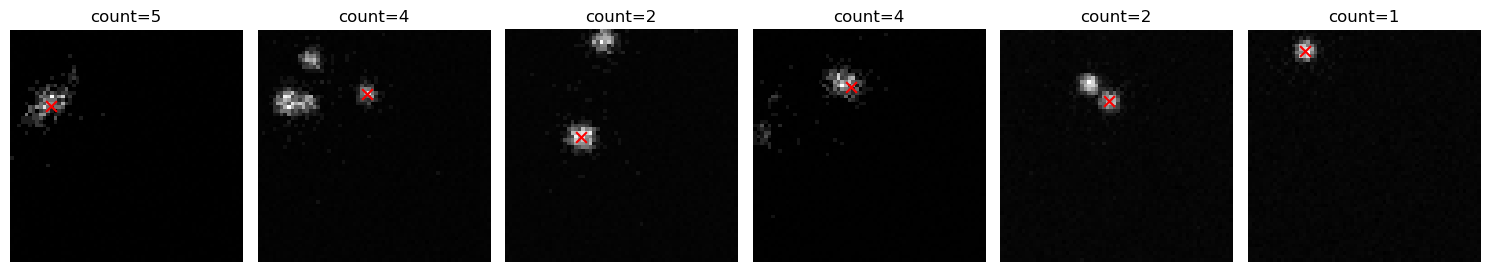

In [49]:
idx = np.random.choice(len(images_loc), size=6, replace=False)

plt.figure(figsize=(15, 3))
for i, j in enumerate(idx):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images_loc[j], cmap="gray", origin="upper")
    y, x = coords_px[j]
    plt.scatter(x, y, c="r", marker="x", s=60)
    plt.title(f"count={int(counts[j])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Normalize target coordinates

In [50]:
H, W = images_loc.shape[1], images_loc.shape[2]

coords = coords_px.copy()
coords[:, 0] = coords[:, 0] / (H - 1)   # y
coords[:, 1] = coords[:, 1] / (W - 1)   # x

In [51]:
# dataset class
class ParticleLocalizationDataset(Dataset):
    def __init__(self, images, coords):
        self.images = images.astype(np.float32)
        self.coords = coords.astype(np.float32)

        H, W = self.images.shape[1], self.images.shape[2]
        yy, xx = np.meshgrid(
            np.linspace(0, 1, H, dtype=np.float32),
            np.linspace(0, 1, W, dtype=np.float32),
            indexing="ij"
        )
        self.coord_channels = np.stack([yy, xx], axis=0)  # (2, H, W)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx][None, :, :]  # (1, H, W)
        image = np.concatenate([image, self.coord_channels], axis=0)  # (3, H, W)
        target = self.coords[idx]
        return torch.tensor(image, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

full_dataset = ParticleLocalizationDataset(images_loc, coords)

## Split data into train / validation / test

In [52]:
generator = torch.Generator().manual_seed(SEED)

n_total = len(full_dataset)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=generator
)

print(n_train, n_val, n_test)

7000 1500 1500


In [53]:
# data loaders
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [54]:
# training/evaluation functions
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    criterion = nn.SmoothL1Loss(beta=0.5)
    mse_meter = 0.0
    mae_px_meter = 0.0
    n = 0

    for images, targets in loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        with torch.set_grad_enabled(training):
            preds = model(images)
            loss = criterion(preds, targets)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        batch_size = images.size(0)
        mse_meter += loss.item() * batch_size
        mae_px_meter += mae_in_pixels(preds.detach().cpu(), targets.detach().cpu()) * batch_size
        n += batch_size

    return mse_meter / n, mae_px_meter / n


def train_model(model, train_loader, val_loader, epochs=80, lr=5e-4, patience=12):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    best_state = None
    best_val = float("inf")
    wait = 0
    history = []

    for epoch in tqdm(range(epochs), desc="Training epochs"):
        t0 = time()

        train_loss, train_mae = run_epoch(model, train_loader, optimizer)
        val_loss, val_mae = run_epoch(model, val_loader)

        history.append((train_loss, train_mae, val_loss, val_mae))

        tqdm.write(
            f"Epoch {epoch+1:03d}/{epochs} | "
            f"train loss={train_loss:.4f}, train MAE={train_mae:.3f}px | "
            f"val loss={val_loss:.4f}, val MAE={val_mae:.3f}px | "
            f"time={time()-t0:.1f}s"
        )

        if val_mae < best_val:
            best_val = val_mae
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                tqdm.write("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return model, history


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Define architectures

In [55]:
class LocNetB2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 5, padding=2), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128), nn.ReLU(),
            nn.Linear(128, 32), nn.ReLU(),
            nn.Linear(32, 2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.head(self.features(x))


class LocNetC2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 5, padding=2), nn.ReLU(),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64), nn.ReLU(),
            nn.Linear(64, 2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.head(self.features(x))


class LocNetH(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 64), nn.ReLU(),
            nn.Linear(64, 2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.head(self.features(x))

In [56]:
sample_images, sample_targets = next(iter(train_loader))
print("Batch image shape:", sample_images.shape)
print("Batch target shape:", sample_targets.shape)

test_model = LocNetB2().to(DEVICE)
with torch.no_grad():
    out = test_model(sample_images.to(DEVICE))
print("Model output shape:", out.shape)
print("Parameter count:", count_params(test_model))

Batch image shape: torch.Size([64, 3, 64, 64])
Batch target shape: torch.Size([64, 2])
Model output shape: torch.Size([64, 2])
Parameter count: 2162754


## Adapted baseline architecture on the hard dataset

In [57]:
# baseline part
baseline_model, baseline_history = train_model(
    LocNetB2(), train_loader, val_loader,
    epochs=40, lr=1e-3, patience=6
)

baseline_test_mse, baseline_test_mae = run_epoch(baseline_model, test_loader)

print("Baseline Q3 architecture on hard dataset")
print("Test MSE:", baseline_test_mse)
print("Test MAE (px):", baseline_test_mae)
print("Parameters:", count_params(baseline_model))

Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 001/40 | train loss=0.0153, train MAE=6.283px | val loss=0.0119, val MAE=5.602px | time=4.4s
Epoch 002/40 | train loss=0.0098, train MAE=5.014px | val loss=0.0065, val MAE=3.936px | time=3.9s
Epoch 003/40 | train loss=0.0094, train MAE=4.746px | val loss=0.0177, val MAE=7.057px | time=4.0s
Epoch 004/40 | train loss=0.0093, train MAE=4.766px | val loss=0.0068, val MAE=4.004px | time=3.8s
Epoch 005/40 | train loss=0.0058, train MAE=3.542px | val loss=0.0032, val MAE=2.565px | time=3.9s
Epoch 006/40 | train loss=0.0028, train MAE=2.367px | val loss=0.0025, val MAE=2.151px | time=3.5s
Epoch 007/40 | train loss=0.0022, train MAE=2.026px | val loss=0.0023, val MAE=2.081px | time=3.8s
Epoch 008/40 | train loss=0.0019, train MAE=1.899px | val loss=0.0021, val MAE=1.999px | time=3.9s
Epoch 009/40 | train loss=0.0017, train MAE=1.759px | val loss=0.0019, val MAE=1.831px | time=3.7s
Epoch 010/40 | train loss=0.0018, train MAE=1.827px | val loss=0.0019, val MAE=1.845px | time=3.7s
Epoch 011/

In [58]:
models = {
    "LocNetB2": LocNetB2(),
    "LocNetC2": LocNetC2(),
    "LocNetH": LocNetH(),
}

results = []
trained_models = {}
histories = {}

for name, model in models.items():
    trained_model, history = train_model(
        model, train_loader, val_loader,
        epochs=80, lr=5e-4, patience=12
    )
    test_mse, test_mae_px = run_epoch(trained_model, test_loader)

    trained_models[name] = trained_model
    histories[name] = history

    results.append({
        "model": name,
        "params": count_params(trained_model),
        "test_mse": test_mse,
        "test_mae_px": test_mae_px,
    })

results_df = pd.DataFrame(results).sort_values(["test_mae_px", "params"])
results_df

Training epochs:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 001/80 | train loss=0.0196, train MAE=6.966px | val loss=0.0139, val MAE=6.236px | time=3.9s
Epoch 002/80 | train loss=0.0127, train MAE=5.857px | val loss=0.0118, val MAE=5.639px | time=4.2s
Epoch 003/80 | train loss=0.0122, train MAE=5.736px | val loss=0.0111, val MAE=5.537px | time=3.7s
Epoch 004/80 | train loss=0.0090, train MAE=4.773px | val loss=0.0063, val MAE=3.783px | time=3.8s
Epoch 005/80 | train loss=0.0058, train MAE=3.630px | val loss=0.0045, val MAE=3.115px | time=3.6s
Epoch 006/80 | train loss=0.0054, train MAE=3.443px | val loss=0.0041, val MAE=2.924px | time=3.7s
Epoch 007/80 | train loss=0.0037, train MAE=2.757px | val loss=0.0034, val MAE=2.642px | time=3.8s
Epoch 008/80 | train loss=0.0030, train MAE=2.462px | val loss=0.0028, val MAE=2.336px | time=3.5s
Epoch 009/80 | train loss=0.0027, train MAE=2.299px | val loss=0.0025, val MAE=2.177px | time=3.5s
Epoch 010/80 | train loss=0.0025, train MAE=2.204px | val loss=0.0038, val MAE=2.780px | time=4.6s
Epoch 011/

Training epochs:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 001/80 | train loss=0.0200, train MAE=6.770px | val loss=0.0103, val MAE=5.086px | time=3.1s
Epoch 002/80 | train loss=0.0090, train MAE=4.788px | val loss=0.0079, val MAE=4.389px | time=3.3s
Epoch 003/80 | train loss=0.0072, train MAE=4.182px | val loss=0.0081, val MAE=4.478px | time=3.2s
Epoch 004/80 | train loss=0.0066, train MAE=3.934px | val loss=0.0053, val MAE=3.449px | time=3.3s
Epoch 005/80 | train loss=0.0051, train MAE=3.378px | val loss=0.0047, val MAE=3.225px | time=3.3s
Epoch 006/80 | train loss=0.0049, train MAE=3.273px | val loss=0.0042, val MAE=2.994px | time=3.0s
Epoch 007/80 | train loss=0.0038, train MAE=2.841px | val loss=0.0034, val MAE=2.640px | time=3.3s
Epoch 008/80 | train loss=0.0035, train MAE=2.711px | val loss=0.0033, val MAE=2.574px | time=3.2s
Epoch 009/80 | train loss=0.0032, train MAE=2.541px | val loss=0.0031, val MAE=2.449px | time=2.9s
Epoch 010/80 | train loss=0.0037, train MAE=2.757px | val loss=0.0052, val MAE=3.369px | time=3.1s
Epoch 011/

Training epochs:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 001/80 | train loss=0.0150, train MAE=6.250px | val loss=0.0120, val MAE=5.611px | time=3.6s
Epoch 002/80 | train loss=0.0120, train MAE=5.707px | val loss=0.0105, val MAE=5.326px | time=4.2s
Epoch 003/80 | train loss=0.0103, train MAE=5.097px | val loss=0.0106, val MAE=5.278px | time=3.7s
Epoch 004/80 | train loss=0.0089, train MAE=4.700px | val loss=0.0065, val MAE=3.902px | time=4.0s
Epoch 005/80 | train loss=0.0069, train MAE=4.025px | val loss=0.0059, val MAE=3.722px | time=4.0s
Epoch 006/80 | train loss=0.0055, train MAE=3.519px | val loss=0.0050, val MAE=3.294px | time=4.2s
Epoch 007/80 | train loss=0.0039, train MAE=2.901px | val loss=0.0037, val MAE=2.768px | time=4.0s
Epoch 008/80 | train loss=0.0033, train MAE=2.585px | val loss=0.0029, val MAE=2.413px | time=3.8s
Epoch 009/80 | train loss=0.0035, train MAE=2.621px | val loss=0.0029, val MAE=2.385px | time=4.2s
Epoch 010/80 | train loss=0.0027, train MAE=2.265px | val loss=0.0035, val MAE=2.685px | time=3.6s
Epoch 011/

[{'model': 'LocNetB2',
  'params': 2162754,
  'test_mse': 0.0011057260467981298,
  'test_mae_px': 1.2615766604741414},
 {'model': 'LocNetC2',
  'params': 530898,
  'test_mse': 0.0014306296333670616,
  'test_mae_px': 1.5097421204249064},
 {'model': 'LocNetH',
  'params': 1083922,
  'test_mse': 0.0009989712191745639,
  'test_mae_px': 1.2147333019574482}]

In [59]:
results_df = pd.DataFrame(results).sort_values(["test_mae_px", "params"])
display(results_df)

below_1px = results_df[results_df["test_mae_px"] < 1.0].sort_values("params")
display(below_1px)

if len(below_1px) > 0:
    smallest_success = below_1px.iloc[0]
    print("Smallest tested model with test MAE < 1 pixel:")
    print(smallest_success)
else:
    print("No tested model achieved test MAE < 1 pixel.")

,model,params,test_mse,test_mae_px
2,LocNetH,1083922,0.000999,1.214733
0,LocNetB2,2162754,0.001106,1.261577
1,LocNetC2,530898,0.001431,1.509742


,model,params,test_mse,test_mae_px


No tested model achieved test MAE < 1 pixel.


Best model: LocNetH


Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 001/40 | train loss=0.0150, train MAE=6.217px | val loss=0.0119, val MAE=5.715px | time=3.0s
Epoch 002/40 | train loss=0.0124, train MAE=5.807px | val loss=0.0120, val MAE=5.777px | time=3.0s
Epoch 003/40 | train loss=0.0119, train MAE=5.677px | val loss=0.0104, val MAE=4.959px | time=3.3s
Epoch 004/40 | train loss=0.0065, train MAE=3.942px | val loss=0.0042, val MAE=3.070px | time=4.2s
Epoch 005/40 | train loss=0.0033, train MAE=2.642px | val loss=0.0026, val MAE=2.291px | time=3.4s
Epoch 006/40 | train loss=0.0024, train MAE=2.160px | val loss=0.0022, val MAE=2.012px | time=3.2s
Epoch 007/40 | train loss=0.0020, train MAE=1.938px | val loss=0.0020, val MAE=1.879px | time=3.8s
Epoch 008/40 | train loss=0.0024, train MAE=2.079px | val loss=0.0020, val MAE=1.878px | time=3.8s
Epoch 009/40 | train loss=0.0018, train MAE=1.788px | val loss=0.0017, val MAE=1.726px | time=3.4s
Epoch 010/40 | train loss=0.0015, train MAE=1.642px | val loss=0.0016, val MAE=1.673px | time=3.4s
Epoch 011/

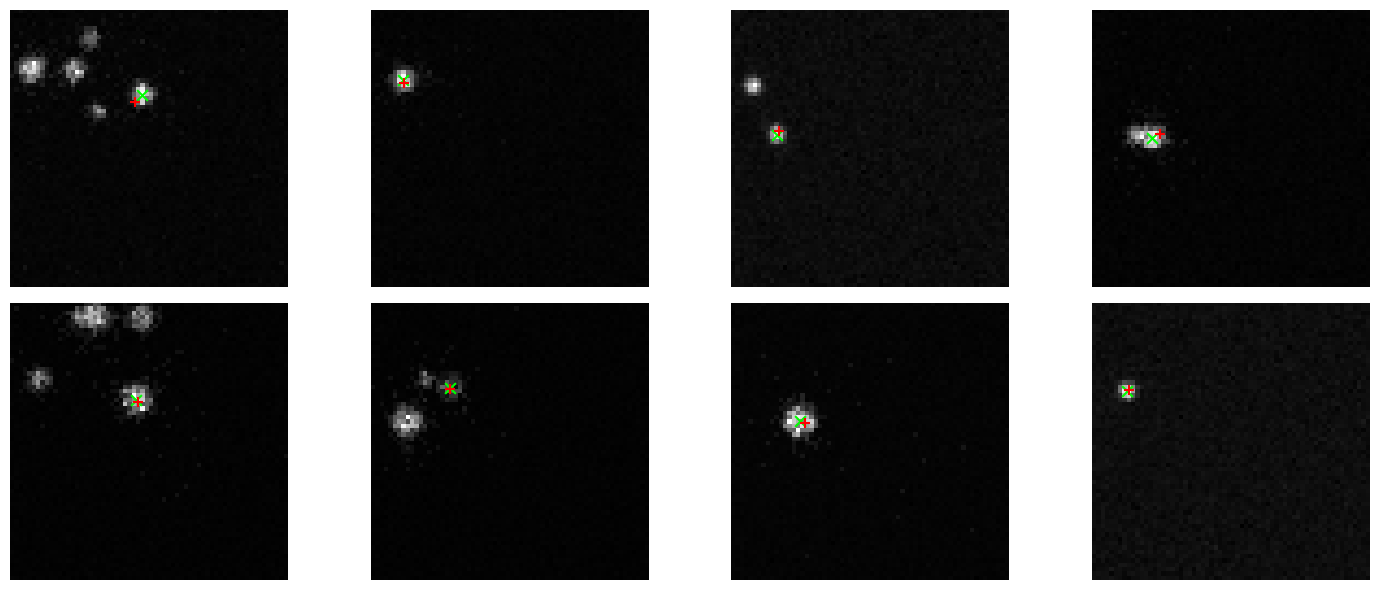

In [60]:
best_model_name = results_df.iloc[0]["model"]
print("Best model:", best_model_name)

best_model = trained_models[best_model_name]
best_model.eval()

images_batch, targets_batch = next(iter(test_loader))
images_batch = images_batch.to(DEVICE)

with torch.no_grad():
    preds_batch = best_model(images_batch).cpu()

images_batch = images_batch.cpu()
targets_batch = targets_batch.cpu()

preds_px = preds_batch.clone()
targets_px = targets_batch.clone()

preds_px[:, 0] *= (H - 1)
preds_px[:, 1] *= (W - 1)
targets_px[:, 0] *= (H - 1)
targets_px[:, 1] *= (W - 1)

plt.figure(figsize=(15, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray", origin="upper")
    ty, tx = targets_px[i]
    py, px = preds_px[i]
    plt.scatter(tx, ty, c="lime", marker="x", s=60)
    plt.scatter(px, py, c="red", marker="+", s=60)
    plt.axis("off")
plt.tight_layout()
plt.show()

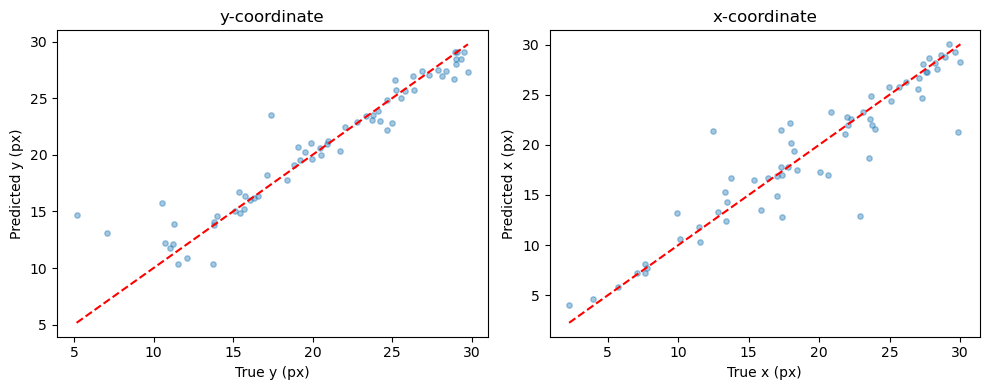

In [61]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(targets_px[:, 0], preds_px[:, 0], alpha=0.4, s=15)
mn = min(targets_px[:, 0].min(), preds_px[:, 0].min())
mx = max(targets_px[:, 0].max(), preds_px[:, 0].max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("True y (px)")
plt.ylabel("Predicted y (px)")
plt.title("y-coordinate")

plt.subplot(1, 2, 2)
plt.scatter(targets_px[:, 1], preds_px[:, 1], alpha=0.4, s=15)
mn = min(targets_px[:, 1].min(), preds_px[:, 1].min())
mx = max(targets_px[:, 1].max(), preds_px[:, 1].max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("True x (px)")
plt.ylabel("Predicted x (px)")
plt.title("x-coordinate")

plt.tight_layout()
plt.show()

The hard dataset is substantially more difficult than the simple dataset because multiple particles may be present, while the label corresponds only to the particle closest to the image center. The direct Q3 regressor performs poorly on this harder selection rule, but the revised architecture improves performance significantly over the Q3-style direct regressor. 
Performance improves when absolute position information is provided explicitly through coordinate channels and when spatial information is preserved more carefully in the CNN. We can see that the remaining error is modest and likely driven by multi-particle ambiguity near the center.

-------------------------------------------------------------------------------------------------------------------------------------------------